# CLASSIFICATION & CLUSTERING MODELS

**Data Description:** The dataset contains 12,330 recorded sessions where 84.5% (10,422) were negative class samples that did not end with shopping, and the rest (1,908) were positive class samples ending with shopping, which could cause a serious problem negatively impacting company's revenue and market share in future. The dataset comprises feature vectors with each session associated with a unique user over the span of one year.

**Domain:** Online shopper behavior, e-commerce

### Goals
This notebook is a submission for Assignment 3 of Group 4. The primary objective is to analyse and build data models for the **Online Shoppers Purchasing Intention Dataset** dataset sourced from UCI Machine Learning Repository. The dataset will undergo a pre-processing step to be ready for analysis. Once cleaned, a comprehensive exploratory data analysis will be performed, followed by the development of two classification models and two clustering models. Finally, model's performance will be evaluated and best models will be recommend.

* For the classification models, this notebook will employ Random Forest Classification and Stacking Model to tackle the binary-class classification problem, measuring the user’s intention to finalize the transaction.
* For the clustering models, this notebook willl apply K-Means and DBSCAN models to segment users based on 4 main features **`ProductRelated`**, **`ProductRelated_Duration`**, **`BounceRates`**, **`ExitRates`**


### The steps are broadly divided into:

1. [Step 1: Reading, Understanding and Preparing Data](#1)
1. [Step 2: Exploratory Data Analysis](#2)
1. [Step 3: Feature Selection](#3)
1. [Step 4: Model Approach](#4)
1. [Step 5: Model evaluation](#5)

### Required Libraries and Utilities

In [2]:
# Importing packages - Pandas, Numpy, Seaborn, Scipy
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, sys
import matplotlib.gridspec as gridspec
import plotly.express as px
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, RepeatedStratifiedKFold, cross_val_score, cross_validate
from sklearn.metrics import silhouette_score, make_scorer, mean_squared_error, precision_score, recall_score, accuracy_score, confusion_matrix, f1_score, auc, roc_auc_score, r2_score, roc_curve, precision_recall_curve, classification_report, matthews_corrcoef
from sklearn.feature_selection import mutual_info_classif, SelectKBest, chi2, SelectFromModel, RFE
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from collections import Counter
from imblearn.combine import SMOTEENN
from imblearn.under_sampling import EditedNearestNeighbours
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.cluster import DBSCAN, KMeans

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# To display all the columns/ rows
pd.options.display.max_columns = None
pd.options.display.max_rows = None

# To map Empty Strings or numpy.inf as Na Values
pd.options.mode.use_inf_as_na = True
pd.options.display.expand_frame_repr =  False

%matplotlib inline

# Set Style
import matplotlib.style as style; style.use('fivethirtyeight')
sns.set(style = "whitegrid")

# Step 1: Reading, Understanding and Preparing Data

At this step, I begin by checking for any missing values, inconsistencies in data types, or other issues in the dataset.

In [3]:
# Reading the data as data frame and print the first five rows
file_name = 'online_shoppers_intention.csv'
df = pd.read_csv(file_name, sep=',', decimal='.')
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


### Data Description


Attribute Name (Numerical) | Attribute Description | Type of Variable | Min-Max Values
------------- | ------------- | ------------- | --------------
Administative	| Number of 'administrative' pages viewed	| Numerical (Discrete)|Min is 0 and max is 27
Administrative_Duration	| Total amount of time (in seconds) spent by the visitor on 'administrative' pages	| Numerical (Continuous) | Min is 0 and max is 3,398.75
Informational	| Number of 'informational' pages viewed | Numerical (Discrete)| Min is 0 and max is 24
Informational_Duration	| Total amount of time (in seconds) spent by the visitor on 'informational' pages |  Numerical (Continuous)| Min is 0 and max is 2,549.37
ProductRelated	| Number of 'product related' pages viewed	| Numerical (Discrete)| Min is 0 and max is 705
ProductRelated_Duration	| Total amount of time (in seconds) spent by the visitor on 'product related' pages	|Numerical (Continuous)|  Min is 0 and max is 63,973.52
BounceRates	| Average bounce rate value of visitors who enter the site from that page and then leave ("bounce") without triggering any other requests to the analytics server during that session	| Quantitative, Continuous	| Min is 0 and max is 0.2
ExitRates	|  Average exit rate value of the pages visited by the visitor |Quantitative, Continuous| Min is 0 and max is 0.2
PageValues	| Average page value of the pages visited by the visitor	| Quantitative, Continuous	| Min is 0 and max is 361
SpecialDay	| Closeness of the site visiting time to a special day (e.g. Mother's Day, Valentine's Day) in which the sessions are more likely to be finalized with transaction	| Quantitative, Continuous| Min is 0 and max is 1

\\

Attribute Name (Categorical) | Attribute Description | Type of Variable | Min-Max Values
------------- | ------------- | ------------- | --------------
Month	| Month value of the visit date (Feb, Mar, May, June, Jul, Aug, Sep, Oct, Nov, Dec) | Ordinal | *Listed in the attribute description*
OperatingSystems	| Operating system used for the session	| Nominal| From 1 to 8
Browser	| Browser used for the session	| Nominal| From 1 to 13
Region	| Geographic region from which the session has been started by the visitor| Nominal| From 1 to 9
TrafficType | Traffic source by which the visitor has arrived at the Web site (e.g., banner, SMS, direct) | Nominal| From 1 to 20
VisitorType	| Type of visitors (New Vistor, Returning Visitor, and Other) 	|Nominal	| *Listed in the attribute description*
Weekend	| Whether the session occured on weekend	| Binary| True, False
Revenue	| When a user's online session results in a completed purchase the value is True otherwise False 	| Binary| True, False

**Description:** The dataset has 12,330 rows and 18 columns, with no missing values. Every one line of record for each session belonging to different user in a 1-year period.

In [4]:
# Get info & data types of the dataframe columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [5]:
# Display features that contain null value
df[df.isna().any(axis=1)].count()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

**Description:** The dataset has 125 duplicated rows that should be removed.

In [6]:
# Check and remove duplicates
duplicates = df.duplicated()
print("There are {} duplicated rows".format(len(df[duplicates])))

# Print 5 duplicate rows
df[duplicates].head()

There are 125 duplicated rows


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
158,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
159,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
178,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
418,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,1,1,1,1,Returning_Visitor,True,False
456,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,2,2,4,1,Returning_Visitor,False,False


In [7]:
# Remove duplicated values
df = df.drop_duplicates().reset_index(drop=True)

### Ensuring Data Integrity

**Description:** No missing or inconsistent values detected. The dataset is clean and ready for further analysis.

In [8]:
for col in df.columns:
    if df[col].dtype == 'object':  # For categorical columns
        print(f"Column: {col}")
        print(df[col].value_counts(), "\n")
    else:  # For numerical columns
        print(f"Column: {col}")
        print(df[col].describe(), "\n")

Column: Administrative
count    12205.000000
mean         2.338878
std          3.330436
min          0.000000
25%          0.000000
50%          1.000000
75%          4.000000
max         27.000000
Name: Administrative, dtype: float64 

Column: Administrative_Duration
count    12205.000000
mean        81.646331
std        177.491845
min          0.000000
25%          0.000000
50%          9.000000
75%         94.700000
max       3398.750000
Name: Administrative_Duration, dtype: float64 

Column: Informational
count    12205.000000
mean         0.508726
std          1.275617
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         24.000000
Name: Informational, dtype: float64 

Column: Informational_Duration
count    12205.000000
mean        34.825454
std        141.424807
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       2549.375000
Name: Informational_Duration, dtype: float64 

Column: ProductR

In [9]:
# Convert specified columns to categorical
convert_cols = ['OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType']
df[convert_cols] = df[convert_cols].apply(lambda col: col.astype('category'))

# Re-check datatypes
df.dtypes

Administrative                int64
Administrative_Duration     float64
Informational                 int64
Informational_Duration      float64
ProductRelated                int64
ProductRelated_Duration     float64
BounceRates                 float64
ExitRates                   float64
PageValues                  float64
SpecialDay                  float64
Month                        object
OperatingSystems           category
Browser                    category
Region                     category
TrafficType                category
VisitorType                category
Weekend                        bool
Revenue                        bool
dtype: object

# Step 2: Exploratory Data Analysis

### 1. Define function set up

In [10]:
# Custom Function to add data labels in the graph

def add_data_labels(ax, spacing = 5):

    # For each bar: Place a label
    for rect in ax.patches:
        # Get X and Y placement of label from rect.
        y_value = rect.get_height()
        x_value = rect.get_x() + rect.get_width() / 2

        # Number of points between bar and label. Change to your liking.
        space = spacing
        # Vertical alignment for positive values
        va = 'bottom'

        # If value of bar is negative: Place label below bar
        if y_value < 0:
            # Invert space to place label below
            space *= -1
            # Vertically align label at top
            va = 'top'

        # Use Y value as label and format number with one decimal place
        label = "{:.2f}%".format(y_value)

        # Create annotation
        plt.annotate(
            label,                        # Use `label` as label
            (x_value, y_value),           # Place label at end of the bar
            xytext = (0, space),          # Vertically shift label by `space`
            textcoords = "offset points", # Interpret `xytext` as offset in points
            ha = 'center')                      # Vertically align label differently for positive and negative values.

In [11]:
# Set up plots to explore individual columns
def explore_column(column_name, column_type, plot_type=None):
    plt.figure(figsize=(6, 5))
    if column_type == 'categorical':
        series = round(((df[column_name].value_counts(dropna = False))/
                        (len(df[column_name])) * 100), 2)

        ax = sns.barplot(x = series.index, y = series.values, order = series.sort_index().index, palette='inferno')
        plt.xlabel(column_name, labelpad = 15)
        plt.ylabel('Count', labelpad = 10)
        add_data_labels(ax)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
        plt.subplots_adjust(hspace = 0.3, wspace = 0.5)
        plt.title(f'Distribution of {column_name}', fontweight='bold')

    elif column_type == 'continuous':
        if plot_type == 'hist':
            ax = sns.histplot(df[column_name], kde=True, color='blue', bins=30)
            plt.ylabel('Density')
        elif plot_type == 'boxplot':
            ax = sns.boxplot(df[column_name], palette='inferno')
            plt.ylabel('Distribution')

        plt.title(f'Distribution of {column_name}', fontweight='bold')
        plt.xlabel(column_name)

    plt.tight_layout(pad=30.0)
    plt.show()

In [12]:
def plotting_2_chart(df, feature):
    ## Creating a customized chart. and giving in figsize and everything.
    fig = plt.figure(constrained_layout=True, figsize=(10,6))
    ## creating a grid of 2 cols and 2 rows.
    grid = gridspec.GridSpec(ncols=1, nrows=2, figure=fig, hspace=0.7, wspace=0.3)

    fig.suptitle(f'Analysis of {feature}', fontsize=20, fontweight='bold')

    ## Customizing the histogram grid.
    ax1 = fig.add_subplot(grid[0, :1])
    ## Set the title.
    ax1.set_title('Box Plot', fontsize=10)
    ## plot the histogram.
    sns.boxplot(df.loc[:,feature], orient='h', ax = ax1);

    # customizing the QQ_plot.
    ax2 = fig.add_subplot(grid[1, :2])
    ## Set the title.
    ax2.set_title('QQ_plot', fontsize=10)
    ## Plotting the QQ_Plot.
    stats.probplot(df.loc[:,feature], plot = ax2)

    plt.tight_layout()
    plt.show()

In [13]:
# Visualization pairs
def visualize_pair(df, x, y, hue=None):
    plt.figure(figsize=(11, 6))
    if df[y].dtype == "object":  # Target variable is categorical
        if df[x].dtype == "object":  # Both variables are categorical
            sns.countplot(x=x, hue=y, data=df, palette="inferno")
            plt.title(f"Count Plot of {x} by {y}", fontweight='bold')
            plt.ylabel("Count")
        else:  # x is continuous, y is categorical
                sns.boxplot(x=x, y=y, data=df, palette="inferno")
                plt.title(f"{x} vs. {y}", fontweight='bold')
                plt.ylabel(y)
    else:  # y is continuous
        sns.scatterplot(x=x, y=y, data=df, alpha=1, color="blue", hue=hue)
        sns.regplot(x=x, y=y, data=df, scatter=False, color="red", line_kws={"linewidth": 2, "linestyle": "--"})
        plt.title(f"{x} vs. {y}", fontweight='bold')
        plt.ylabel(y)
    plt.xlabel(x)
    plt.tight_layout()
    plt.show()

In [14]:
def box_strip_plot(df, x, y):
    # Create a box and strip plot with a custom legend.
    plt.figure(figsize=(8, 6))
    ax = sns.boxplot(x=x, y=y, palette='afmhot', data=df)
    sns.stripplot(x=x, y=y, palette='afmhot', data=df, jitter=True, dodge=False, linewidth=0.5)

    # Adding legend directly based on unique x values
    plt.legend(title=x, labels=df[x].unique(), loc='upper right')

    # Setting title
    ax.set_title(f"Distribution of {y} by {x}", fontweight='bold')
    plt.show()

In [15]:
def plot_revenue_with_Cat(df, x):
    # Ensure Month is in the correct order if x is 'Month'
    if x == 'Month':
        month_order = [
            'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
            'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
        ]
        df[x] = pd.Categorical(df[x], categories=month_order, ordered=True)
        df = df.sort_values(by=x)

    # Ensure column x is sorted for non-month columns
    elif pd.api.types.is_numeric_dtype(df[x]):
        df = df.sort_values(by=x)
    else:
        df[x] = pd.Categorical(df[x], categories=sorted(df[x].unique()), ordered=True)
        df = df.sort_values(by=x)

    # Prepare data for Chart 1: Frequency of Revenue by Feature x
    frequency_data = df.groupby([x, 'Revenue']).size().reset_index(name='Frequency')

    # Prepare data for Chart 2: Stacked Percentage by Feature x
    stacked_data = frequency_data.copy()
    stacked_data['Proportion'] = stacked_data.groupby(x)['Frequency'].transform(lambda x: x / x.sum())

    # Plot the charts
    sns.set_style("whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Chart 1: Frequency of Revenue by Feature x
    sns.barplot(data=frequency_data, x=x, y='Frequency', hue='Revenue', ax=axes[0], palette="inferno")
    axes[0].set_title(f"Revenue Generation by {x}", fontsize=14, fontweight="bold")
    axes[0].set_xlabel(x, fontsize=12)
    axes[0].set_ylabel("Frequency", fontsize=12)
    axes[0].legend(title="Revenue")

    # Chart 2: Stacked Percentage Chart for Normalized Revenue
    stacked_pivot = stacked_data.pivot_table(
        index=x, columns='Revenue', values='Proportion', fill_value=0
    )
    stacked_pivot.plot(
        kind='bar', stacked=True, colormap='coolwarm', ax=axes[1]
    )
    axes[1].set_title(f"Normalized Revenue Proportion by {x}", fontsize=14, fontweight="bold")
    axes[1].set_xlabel(x, fontsize=12)
    axes[1].set_ylabel("Proportion (%)", fontsize=12)
    axes[1].legend(title="Revenue", bbox_to_anchor=(1.05, 1), loc='upper left')

    # Adjust layout
    plt.tight_layout()
    plt.show()

In [16]:
def plot_stacked_bar_and_kde(df: pd.DataFrame, numerical_col: str, boolean_col: str, bins: np.ndarray = None, plot: int = 2):
    if numerical_col not in df.columns or boolean_col not in df.columns:
        raise ValueError("Both numerical_col and boolean_col must exist in the DataFrame.")

    if bins is None:
        bins = np.arange(df[numerical_col].min(), df[numerical_col].max() + 0.01, 0.01)

    # Create Bins
    df['bin'] = pd.cut(df[numerical_col], bins=bins)

    if plot == 2:
        # --- Plot 1: Stacked Bar Plot ---
        grouped_data = df.groupby(['bin', boolean_col]).size().unstack(fill_value=0)
        grouped_data = grouped_data.div(grouped_data.sum(axis=1), axis=0)  # Normalize to 1

        plt.figure(figsize=(8, 8))

        # Subplot 1: Stacked Bar Plot
        plt.subplot(2, 1, 1)
        grouped_data.plot(
            kind='bar',
            stacked=True,
            ax=plt.gca(),
            color=['#1f77b4', '#ff7f0e']
        )
        plt.title(f'Impact of {numerical_col} on {boolean_col.capitalize()}', fontweight="bold")
        plt.xlabel(numerical_col.capitalize())
        plt.ylabel('Proportion')
        plt.legend(title=boolean_col.capitalize(), labels=['False', 'True'])

        # Subplot 2: KDE Plot
        plt.subplot(2, 1, 2)
        sns.kdeplot(df[df[boolean_col] == True][numerical_col], label='True', shade=True)
        sns.kdeplot(df[df[boolean_col] == False][numerical_col], label='False', shade=True)
        plt.title(f'Distribution of {numerical_col} by {boolean_col.capitalize()}', fontweight="bold")
        plt.xlabel(numerical_col.capitalize())
        plt.ylabel('Density')
        plt.legend(title=boolean_col.capitalize(), loc='upper right')

        plt.tight_layout()
        plt.show()

    elif plot == 1:
        # --- Plot 2: KDE Plot Only ---
        plt.figure(figsize=(10, 6))
        sns.kdeplot(df[df[boolean_col] == True][numerical_col], label='True', shade=True)
        sns.kdeplot(df[df[boolean_col] == False][numerical_col], label='False', shade=True)
        plt.title(f'Distribution of {numerical_col} by {boolean_col.capitalize()}', fontweight="bold")
        plt.xlabel(numerical_col.capitalize())
        plt.ylabel('Density')
        plt.legend(title=boolean_col.capitalize(), loc='upper right')
        plt.tight_layout()
        plt.show()

    else:
        raise ValueError("Invalid value for 'plot'. Use 1 for KDE plot only, or 2 for both plots.")

    df.drop('bin', axis=1, inplace=True)

In [17]:
def train_and_plot(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)

    print('Model accuracy for train set: {0:.3f}'.format(model.score(X_train, y_train)))
    print('Model accuracy for test set: {0:.3f}'.format(model.score(X_test, y_test)))

    y_pred = model.predict(X_test)

    # Classification Report
    print('\n{}'.format(classification_report(y_test, y_pred)))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print('\nConfusion Matrix:\n', cm)

    # Accuracy Score
    auc = accuracy_score(y_test, y_pred)
    print('\nAccuracy Score: ', auc)

    # ROC Curve
    model_roc_auc = roc_auc_score(y_test, model.predict(X_test))
    fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:,1])
    plt.figure(figsize = (10.8 , 6))
    plt.plot(fpr, tpr, label = 'AUC = {})'.\
             format(model_roc_auc))
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic')
    plt.legend(loc = 'lower right')
    plt.show()

    return model

### 2. Visualization

+ For **numerical variables**, descriptive statistics will be used to examine the minimum, maximum, standard deviation, and percentiles to assess data distribution. Depending on data normalisation or skewness, visualizations such as box plots and kde plot will be employed.

`Administrative` | `Administrative_Duration	` | `Informational` | `Informational_Duration`| `ProductRelated` | `ProductRelated_Duration`|`BounceRates` |`ExistRates` |`PageValues` |`SpecialDay`
------ | ------- | --------| -----|---------|----- | ------|-----| ------|-----

\

+ Regarding to **categorical variables**, I will compute the frequency and percentage distribution for each category. To effectively visualize the distribution, bar chart/ pie chart will be utilized.

`Month` | `OperatingSystems` | `Browser` | `Region`| `TrafficType` | `VisitorType`|`Weekend` |`Revenue`
------ | ---------------------------------- | --------| -----|---------|----- | ------|-------

In [18]:
# Separating numerical and categorical variables for future use
cat_vars = ['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']
num_vars = list(set(df.columns) - set(cat_vars + ['Revenue']))

In [19]:
print(cat_vars)
print(num_vars)

['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']
['Informational', 'BounceRates', 'Administrative', 'ProductRelated', 'Administrative_Duration', 'ExitRates', 'SpecialDay', 'Informational_Duration', 'PageValues', 'ProductRelated_Duration']


#### 2.1. Numerical Columns

**Description:** Several key insights based on stats below:
+ **`Administrative`** Users visit an average of 2.34 administrative pages, with moderate variability (std = 3.33). Most users visit between 0 and 4 pages (25th - 75th percentile), with some outliers visiting up to 27 pages.
+ **`Administrative_Duration`** The average time spent on administrative pages is 81.65 seconds, but this has a high variability (std = 177.49 seconds) and a maximum of 3,398.75 seconds, indicating that some users spend considerably more time on administrative pages.
+ **`Informational`** On average, users visit 0.51 informational pages, with low variability (std = 1.28). Most users visit 0 pages, with a few visiting up to 24 pages.
+ **`Informational_Duration`** The average duration spent on informational pages is 34.83 seconds, with high variability (std = 141.43 seconds) and a maximum of 2,549.38 seconds, showing significant outliers.
+ **`ProductRelated`** Users visit an average of 32.05 product-related pages, with a wide variability (std = 44.59). Most users visit between 8 and 38 pages (25th - 75th percentile), and some visit up to 705 pages, suggesting high engagement from some users.
+ **`ProductRelated_Duration`** The average time spent on product-related pages is 1,206.98 seconds (about 20 minutes), with very high variability (std = 1,919.60 seconds) and a maximum of 63,973.52 seconds, indicating extreme differences in user engagement.
+ **`BounceRates`** The average bounce rate is 0.02 (2%), with low variability (std = 0.045) and a maximum of 0.2, showing that most sessions do not immediately exit the website.
+ **`ExistRates`** The average exit rate is 0.041 (4.1%), with a narrow variability (std = 0.046), indicating relatively consistent behavior in terms of users exiting pages. Average exist rates seem higher than the Bounce rates, however, both rates have same maximum percentage values and low 5-point values comparing to others.
+ **`PageValues`** The average page value is 5.95, with a high variability (std = 18.65) and a maximum of 361.76, reflecting significant differences in the value of individual pages.
+ **`SpecialDay`** The average special day score is 0.062, with low variability (std = 0.2), and most values are 0, indicating that the dataset likely contains a small proportion of sessions related to special occasions.

In [20]:
# Basic stats of numerical variables
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
Administrative,12205.0,2.339,3.330,0.0,0.000,1.000,4.000,27.000
Administrative_Duration,12205.0,81.646,177.492,0.0,0.000,9.000,94.700,3398.750
Informational,12205.0,0.509,1.276,0.0,0.000,0.000,0.000,24.000
Informational_Duration,12205.0,34.825,141.425,0.0,0.000,0.000,0.000,2549.375
ProductRelated,12205.0,32.046,44.594,0.0,8.000,18.000,38.000,705.000
ProductRelated_Duration,12205.0,1206.982,1919.601,0.0,193.000,608.943,1477.155,63973.522
BounceRates,12205.0,0.020,0.045,0.0,0.000,0.003,0.017,0.200
ExitRates,12205.0,0.041,0.046,0.0,0.014,0.025,0.049,0.200
PageValues,12205.0,5.950,18.654,0.0,0.000,0.000,0.000,361.764
SpecialDay,12205.0,0.062,0.200,0.0,0.000,0.000,0.000,1.000


**Description:** Columns **`Administrative_Duration`**, **`Informational_Duration`** and **`ProductRelated_Duration`** have extreme outliers.

**Intuition:** Outliers are most severe in **`ProductRelated_Duration`**, whereas **`Informational_Duration`** has relatively fewer extreme values. This could be explain that the **`ProductRelated_Duration`** reflecting stronger user engagement as users tends to spend more time on products rather than administrative and informational pages.

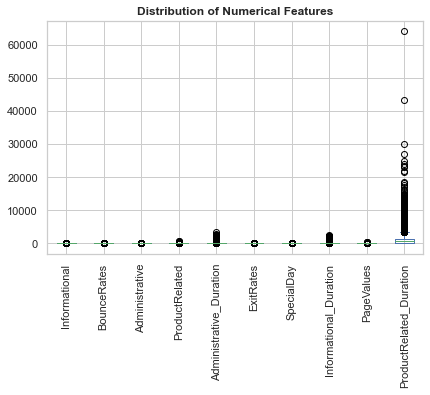

In [21]:
df[num_vars].plot(kind="box")
plt.xticks(rotation=90)
plt.title(f'Distribution of Numerical Features', fontweight='bold')
plt.show()

##### **Administrative_Duration, Informational_Duration and ProductRelated_Duration**

The **`Administrative_Duration`** indicates the total time users spend on administrative pages during their session, providing insights into user engagement with administrative tasks.

**Intuition:**

The distribution of **`Administrative_Duration`** is heavily right-skewed, with the majority of users spending less than 500 seconds on administrative pages. This suggests that most users interact briefly with these pages, likely for basic tasks.\
A significant number of outliers exist, with some durations exceeding 2000 seconds. These could represent users with highly specific or prolonged engagement, possibly due to idle time or complex administrative needs.
The boxplot reinforces the presence of these outliers, as the upper whisker is far from the IQR, highlighting a small subset of extreme cases.

In [22]:
# Count occurrences of each value in the 'Revenue' column where Administrative_Duration > 500
revenue_counts = df[df['Administrative_Duration'] > 500]['Revenue'].value_counts()

# Calculate percentages
revenue_percentages = round(revenue_counts / revenue_counts.sum(), 2) * 100

revenue_distribution = pd.DataFrame({
    'Count': revenue_counts,
    'Percentage': revenue_percentages
})
print(revenue_distribution)

       Count  Percentage
False    250        74.0
True      87        26.0


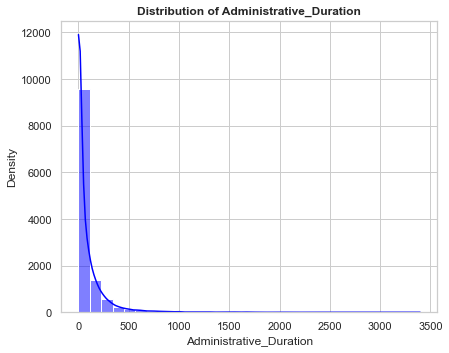

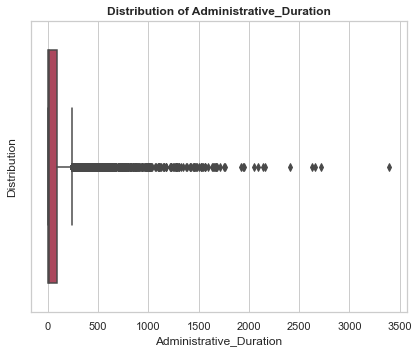

In [23]:
explore_column('Administrative_Duration', 'continuous', 'hist')
explore_column('Administrative_Duration', 'continuous', 'boxplot')

The **`Informational_Duration`** reflects the total time users spend on informational pages during their session, offering insights into how users engage with content aimed at providing information.

**Intuition:** The distribution is heavily right-skewed, with most users spending very little time on informational pages (under 500 seconds). Fewer outliers compared to **`Administrative_Duration`**, with a shorter long tail. This suggests that informational content may not be a primary focus for most users or is quickly consumed. The boxplot highlights the presence of numerous outliers, where durations far exceed the upper whisker, confirming the variability in user behavior.

In [24]:
# Count occurrences of each value in the 'Revenue' column where Informational_Duration > 500
revenue_counts = df[df['Informational_Duration'] > 500]['Revenue'].value_counts()

# Calculate percentages
revenue_percentages = round(revenue_counts / revenue_counts.sum(), 2) * 100

revenue_distribution = pd.DataFrame({
    'Count': revenue_counts,
    'Percentage': revenue_percentages
})
print(revenue_distribution)

       Count  Percentage
False    146        72.0
True      58        28.0


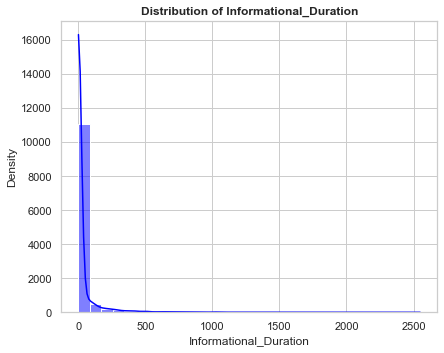

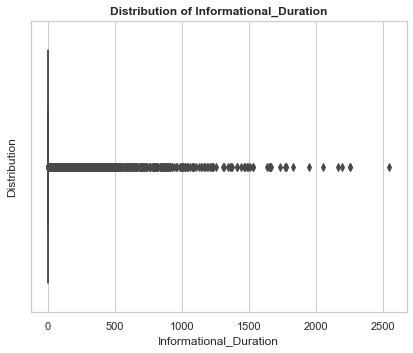

In [25]:
explore_column('Informational_Duration', 'continuous', 'hist')
explore_column('Informational_Duration', 'continuous', 'boxplot')

The **`ProductRelated_Duration`** represents the total time users spend on product-related pages, offering insights into how deeply users engage with product content.

**Intuition:** The distribution is heavily right-skewed, with the majority of users spending less than 10,000 seconds on product-related pages. This suggests that while most users browse product pages briefly, there are cases of prolonged engagement.

In [26]:
# Count occurrences of each value in the 'Revenue' column where ProductRelated_Duration > 10,000
revenue_counts = df[df['ProductRelated_Duration'] > 10000]['Revenue'].value_counts()

# Calculate percentages
revenue_percentages = round(revenue_counts / revenue_counts.sum(), 2) * 100

revenue_distribution = pd.DataFrame({
    'Count': revenue_counts,
    'Percentage': revenue_percentages
})
print(revenue_distribution)

       Count  Percentage
False     50        63.0
True      29        37.0


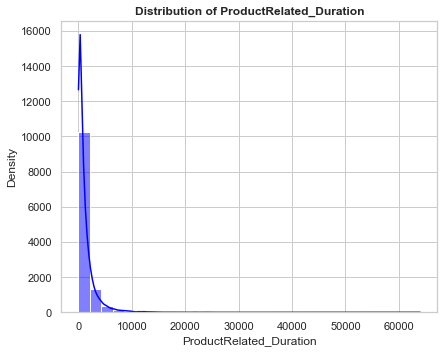

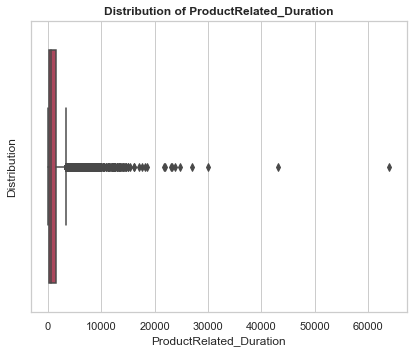

In [27]:
explore_column('ProductRelated_Duration', 'continuous', 'hist')
explore_column('ProductRelated_Duration', 'continuous', 'boxplot')

##### **Outliers Treatement**

Because the distribution of 3 variables is skewed and the only comprises of less than 5% of dataset, we should eliminate ouliers. Since the three duration columns (**`Administrative_Duration`**, **`Informational_Duration`**, **`ProductRelated_Duration`**) are heavily right-skewed and contain extreme outliers, applying both IQR and log transformation is the most robust approach.
+ IQR first ensures extreme outliers are capped to mitigate their influence.
+ Log transformation then normalizes the distribution further for skewed data, making it more suitable for modeling.

In [28]:
# Create copies of the original columns for comparison.
df2 = df.copy()

In [29]:
columns_to_treat = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration']

for column in columns_to_treat:
    # IQR Capping
    Q1 = df2[column].quantile(0.25)
    Q3 = df2[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df2[column] = np.where(df2[column] > upper_bound, upper_bound, df2[column])
    df2[column] = np.where(df2[column] < lower_bound, lower_bound, df2[column])

    # Log Transformation
    df2[f'{column}'] = np.log1p(df2[column])  # log1p handles zero safely

In [30]:
# Before
print("Before Outliers Treatment:")
df[columns_to_treat].describe().T

Before Outliers Treatment:


,count,mean,std,min,25%,50%,75%,max
Administrative_Duration,12205.0,81.646331,177.491845,0.0,0.0,9.000000,94.700000,3398.75000
Informational_Duration,12205.0,34.825454,141.424807,0.0,0.0,0.000000,0.000000,2549.37500
ProductRelated_Duration,12205.0,1206.982457,1919.601400,0.0,193.0,608.942857,1477.154762,63973.52223


**Intuition:** The mean and standard deviation for all three columns have decreased significantly, reflecting a more normalized data distribution. Hence, the median values remain consistent before and after outlier treatment:
+ **`Administrative_Duration`**: 94.70
+ **`ProductRelated_Duration`**: 608.94
This suggests that the core distribution of the data has not been distorted, and only extreme values have been adjusted.

In [31]:
# After
print("After Applying IQR Outliers Removal & Log Transform:")
df2[columns_to_treat].describe().T

After Applying IQR Outliers Removal & Log Transform:


,count,mean,std,min,25%,50%,75%,max
Administrative_Duration,12205.0,2.276391,2.280215,0.0,0.000000,2.302585,4.561218,5.47122
Informational_Duration,12205.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.00000
ProductRelated_Duration,12205.0,5.986741,1.913673,0.0,5.267858,6.413365,7.298550,8.13282


#### 2.2. Revenue

**Description:** The target variable **`Revenue`** contains Boolean values, where:
*   “True” means a purchase was made for revenue generation
*   “False” means no purchase was made and thus no revenue was generated.

It suggests that our machine learning model needs to solve a binary classification problem. The barplot below shows an imbalanced distribution of the target label. The target indicates that out of all consumer browsing sessions, 84% resulted in no purchase, and around 16% resulted in a purchase. We’ll handle this imbalance problems later in the modeling session.

False    10297
True      1908
Name: Revenue, dtype: int64

False    84.37
True     15.63
Name: Revenue, dtype: float64

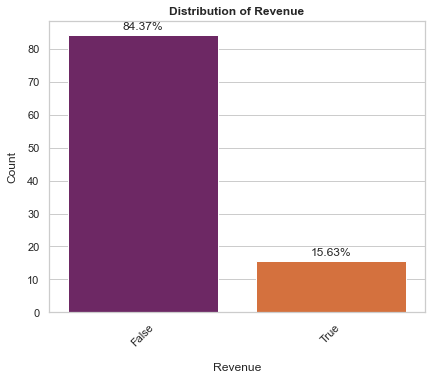

In [32]:
# Distribution of revenue
display(df['Revenue'].value_counts(), (df['Revenue'].value_counts(normalize=True)*100).round(2))
explore_column('Revenue', 'categorical')

#### 2.3. Relationship between Features and Revenue

##### Month vs. Revenue

**Intuition:** The revenue is analysed in each months. It is observed that while March, May, November, and December showed higher activity, it was not clear if these months also had a higher chance of sales. To determine this, we created a probability chart. The second chart revealed that the month generally slightly affects on sales (as the maximum probability of just over 20%). However, October and November show a noticeably higher probability of purchases compared to other months.

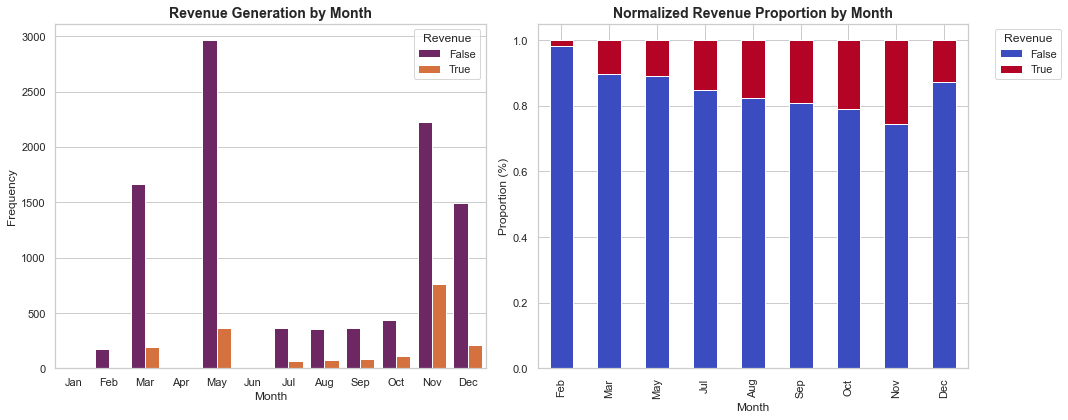

In [33]:
plot_revenue_with_Cat(df, 'Month')

##### OperatingSystems vs. Revenue

**Intuition:** The hypothesis was that Operating System (OS) type 2 users generated the majority of revenue. While a frequency chart showed that user activity concentrated on a few OS types, it did not indicate whether any specific OS influenced purchase probability. The second graph, which is a normalized view demonstrated that OS choice seems to have minimal impact on revenue generation.

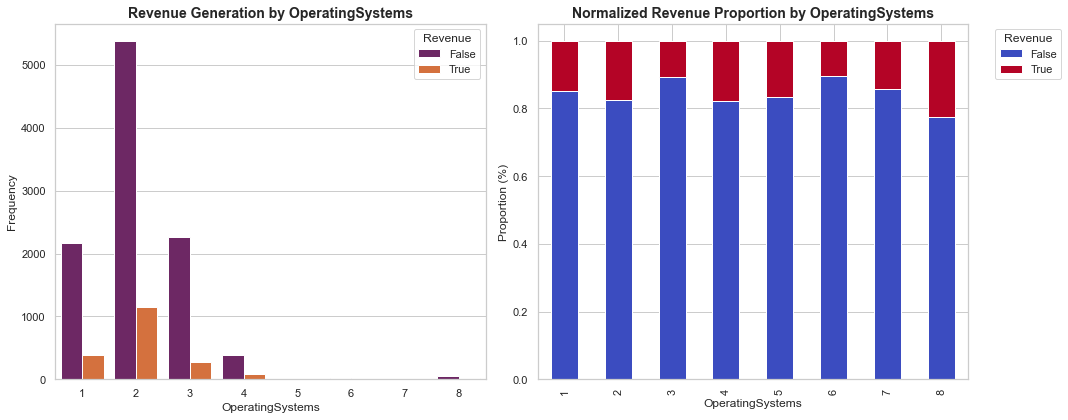

In [34]:
plot_revenue_with_Cat(df, 'OperatingSystems')

##### Browser vs. Revenue

**Intuition:** While the probability graph (second graph) has shown that the Browser 12, 13 has the highest rate of true revenue, most revenue is actually generated from browser 2 and 1, as observed from the first graph. There is little or no contribution from browsers 3,9,11,12,13.



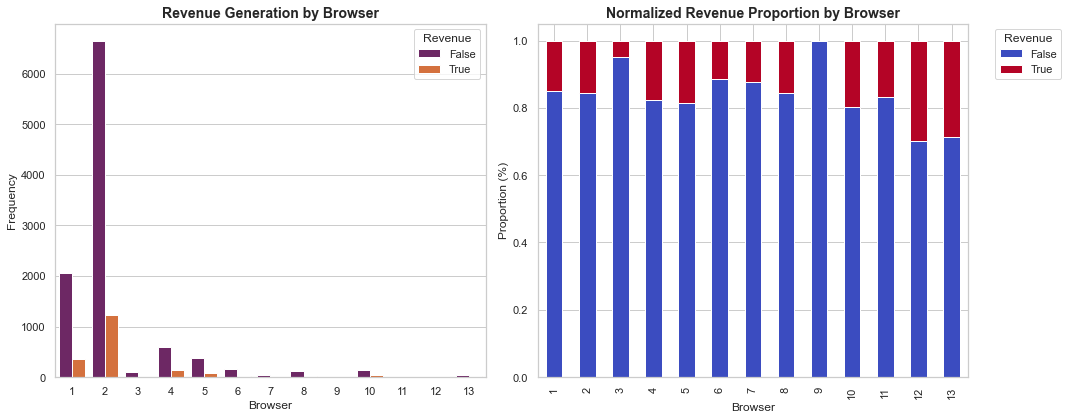

In [35]:
plot_revenue_with_Cat(df, 'Browser')

##### Region vs. Revenue

**Intuition:** Analysis from user region provides valuable insights. Although most website visits come from regions 1, 2, 3, and 4, and much less numbers coming from the rest, a probability chart reveals that the likelihood of generating revenue is relatively consistent across all regions.

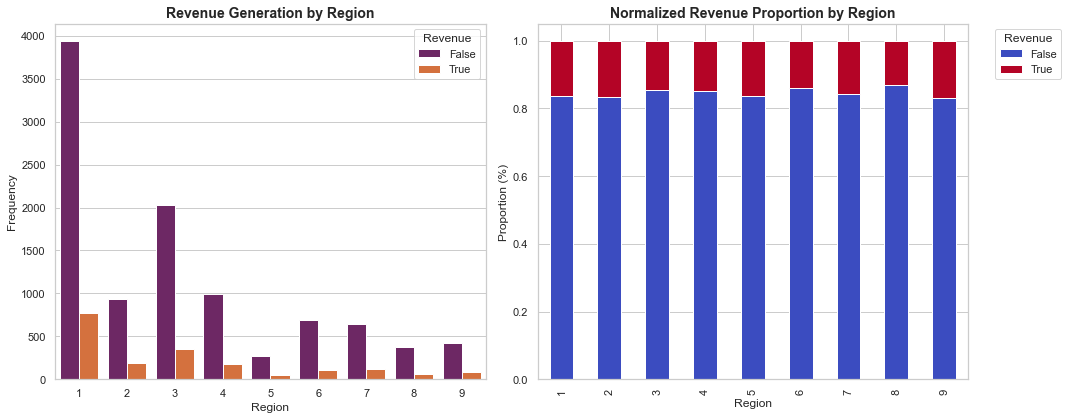

In [36]:
plot_revenue_with_Cat(df, 'Region')

##### TrafficType vs. Revenue

**Intuition:** Most of the traffic hitting the website comes from 1-5 bracket, as observed from the first graph that high numbers appearing in the first five columns. However, the second graph showing the proportions between revenue types in each kinds of traffic proved that the traffic type did not affect the revenue much due to high variability.

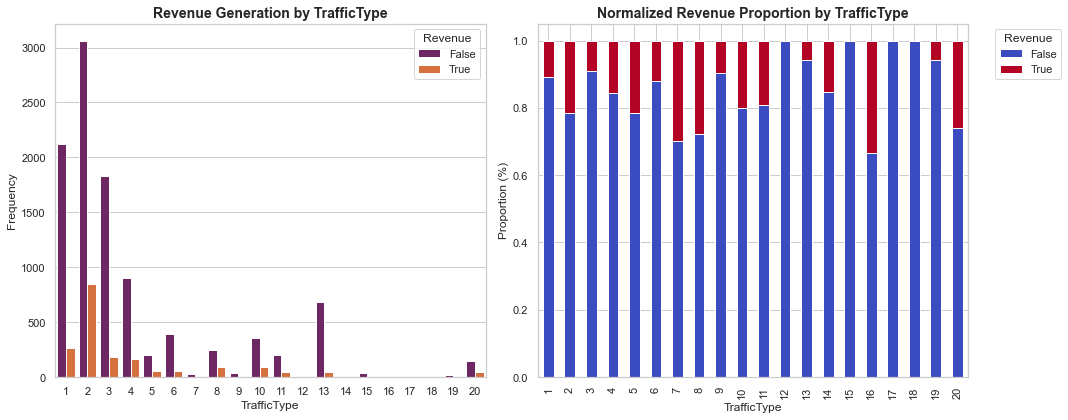

In [37]:
plot_revenue_with_Cat(df, 'TrafficType')

##### VisitorType vs. Revenue

**Intuition:** The bar chart showed that most website visitors (85.5%) are returning customers, while 13.9% are new and only 0.7% fall into an "other" category. Therefore, it is assumed that the returning customers are responsible for most of the website's activity and sales. However, the second graph displayed that new visitors group is the most likely to buy something, as observed from the highest percentage of true revenue, although the difference is not large.

Returning_Visitor    10431
New_Visitor           1693
Other                   81
Name: VisitorType, dtype: int64

Returning_Visitor    85.46
New_Visitor          13.87
Other                 0.66
Name: VisitorType, dtype: float64

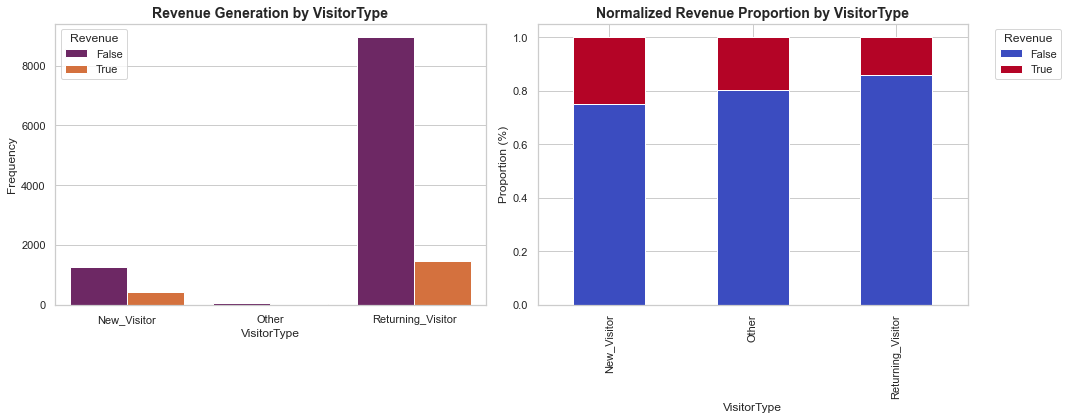

In [39]:
display(df['VisitorType'].value_counts(), (df['VisitorType'].value_counts(normalize=True)*100).round(2))
plot_revenue_with_Cat(df, 'VisitorType')

##### Weekend vs. Revenue

**Intuition:** It is observed that more people visit the website during the week than on weekends, but the likelihood of making a purchase is similar regardless of the time of week.

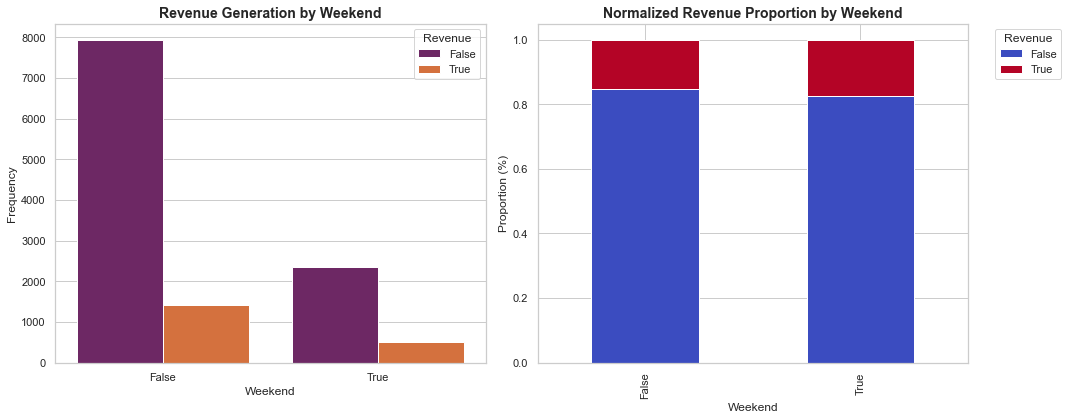

In [40]:
plot_revenue_with_Cat(df, 'Weekend')

##### Visit Pages vs. Revenue

**Initution:** According to the data, customers accessed the ProductRelated webpage more frequently than the Administrative or Informational pages. Based on this observation, the Administrative page appears to function as the website's homepage, while the Informational page serves as the "Contact Us" section, and the ProductRelated page is where detailed product information is presented. However, this contextual information was not originally provided in the dataset.

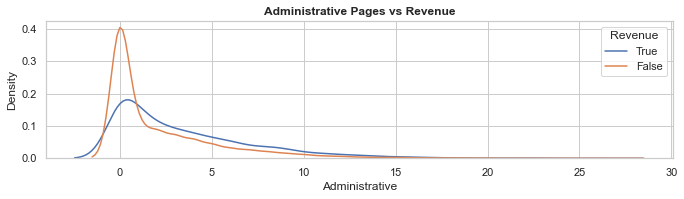

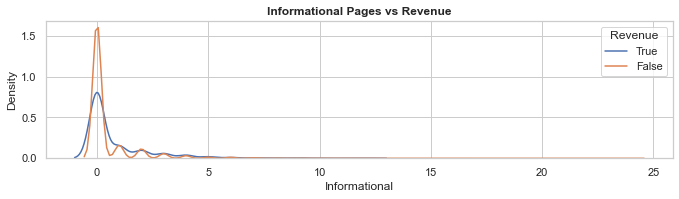

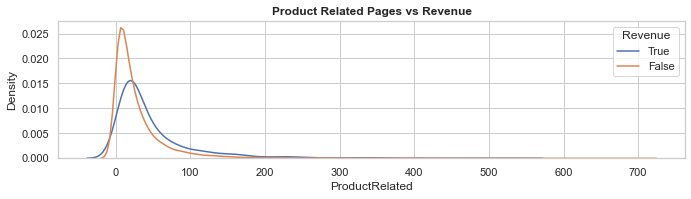

In [41]:
#Visit to pages vs Revenue
plt.figure(figsize=(10,8))

# Administrative_pages
ax1 = plt.subplot(311)
sns.kdeplot(df[df.Revenue == True].Administrative, label='True')
sns.kdeplot(df[df.Revenue == False].Administrative, label='False')
ax1.set_ylabel('Density')
ax1.set_title('Administrative Pages vs Revenue', fontweight="bold")
ax1.legend(title='Revenue', loc='upper right')

# Informational_pages
plt.figure(figsize=(10, 8))
ax2 = plt.subplot(312)
sns.kdeplot(df[df.Revenue == True].Informational, label='True')
sns.kdeplot(df[df.Revenue == False].Informational, label='False')
ax2.set_ylabel('Density')
ax2.set_title('Informational Pages vs Revenue', fontweight="bold")
ax2.legend(title='Revenue', loc='upper right')


# ProductRelated_pages
plt.figure(figsize=(10, 8))
ax3 = plt.subplot(313)
sns.kdeplot(df[df.Revenue == True].ProductRelated, label='True')
sns.kdeplot(df[df.Revenue == False].ProductRelated, label='False')
ax3.set_ylabel('Density')
ax3.set_title('Product Related Pages vs Revenue', fontweight="bold")
ax3.legend(title='Revenue', loc='upper right')

##### Pages Duration vs. Revenue

**Intuition:** Customers who spend most time on product information pages tend to buy the products more than who do not.

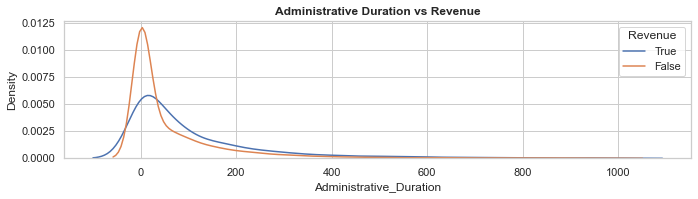

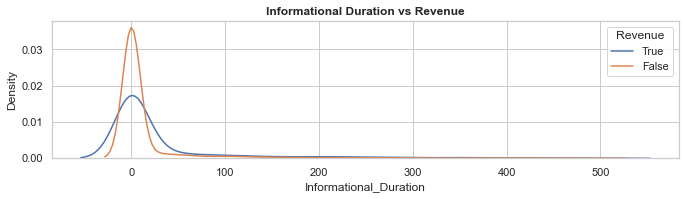

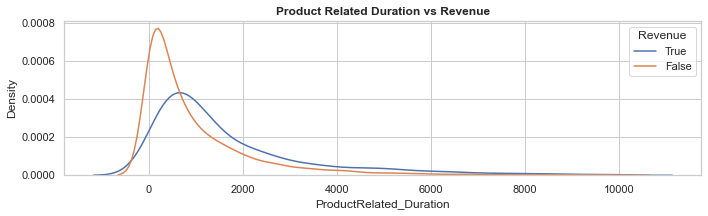

In [42]:
# Page Duration vs Revenue
plt.figure(figsize=(10, 8))

# Administrative_Duration
ax1 = plt.subplot(311)
sns.kdeplot(df[(df.Revenue == True) & (df.Administrative_Duration <= 1000)].Administrative_Duration, label='True')
sns.kdeplot(df[(df.Revenue == False) & (df.Administrative_Duration <= 1000)].Administrative_Duration, label='False')
ax1.set_ylabel('Density')
ax1.set_title('Administrative Duration vs Revenue', fontweight="bold")
ax1.legend(title='Revenue', loc='upper right')

# Informational_Duration
plt.figure(figsize=(10, 8))
ax2 = plt.subplot(312)
sns.kdeplot(df[(df.Revenue == True) & (df.Informational_Duration <= 500)].Informational_Duration, label='True')
sns.kdeplot(df[(df.Revenue == False) & (df.Informational_Duration <= 500)].Informational_Duration, label='False')
ax2.set_ylabel('Density')
ax2.set_title('Informational Duration vs Revenue', fontweight="bold")
ax2.legend(title='Revenue', loc='upper right')

# ProductRelated_Duration
plt.figure(figsize=(10, 8))
ax3 = plt.subplot(313)
sns.kdeplot(df[(df.Revenue == True) & (df.ProductRelated_Duration <= 10000)].ProductRelated_Duration, label='True')
sns.kdeplot(df[(df.Revenue == False) & (df.ProductRelated_Duration <= 10000)].ProductRelated_Duration, label='False')
ax3.set_ylabel('Density')
ax3.set_title('Product Related Duration vs Revenue', fontweight="bold")
ax3.legend(title='Revenue', loc='upper right')

plt.tight_layout()
plt.show()

##### BounceRates vs. Revenue

**Intuition:** Bounce rate has an inverse correlation
with revenue creation. The less the bouncerate values are, the more chances customers will buy the products.

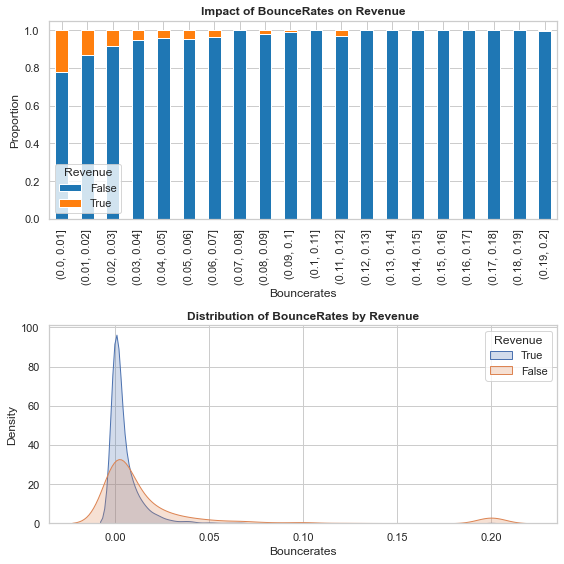

In [43]:
plot_stacked_bar_and_kde(df, 'BounceRates', 'Revenue')

##### ExitRates vs. Revenue

**Intuition:** A lower exit rate is strongly correlated with a higher
likelihood of generating income.

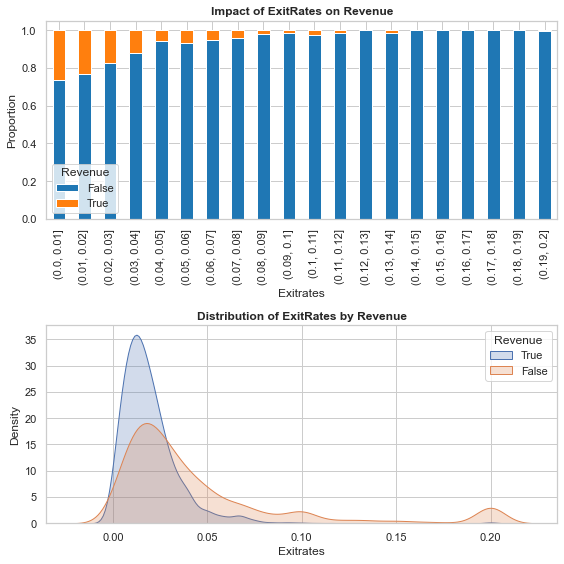

In [44]:
plot_stacked_bar_and_kde(df, 'ExitRates', 'Revenue')

##### PageValues vs. Revenue

**Intuiton:**  The density peak not buying products is much sharper near zero compared to make purchasing, indicating that non-purchasing users tend to interact with low-value pages. A higher **`PageValues`** appears to correlate positively with Revenue, implying that users engaging with higher-value pages are more likely to convert.

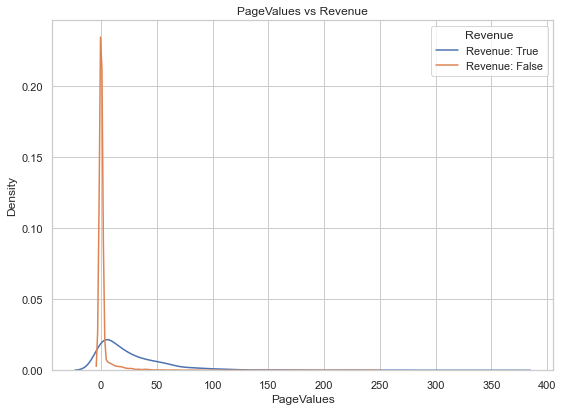

In [45]:
plt.figure(figsize=(8, 6))

# KDE plot for PageValues vs Revenue
sns.kdeplot(df[df.Revenue == True].PageValues, label='Revenue: True')
sns.kdeplot(df[df.Revenue == False].PageValues, label='Revenue: False')

plt.title('PageValues vs Revenue')
plt.ylabel('Density')
plt.xlabel('PageValues')
plt.legend(title='Revenue', loc='upper right')
plt.show()

##### SpecialDay vs. Revenue

**Intuition:** It is indicated that customers' purchasing behavior does not appear to be significantly influenced by the closeness of their online browsing or shopping activities to special days or holidays. The data suggests that purchasing patterns are not strongly correlated with the closeness of these events.

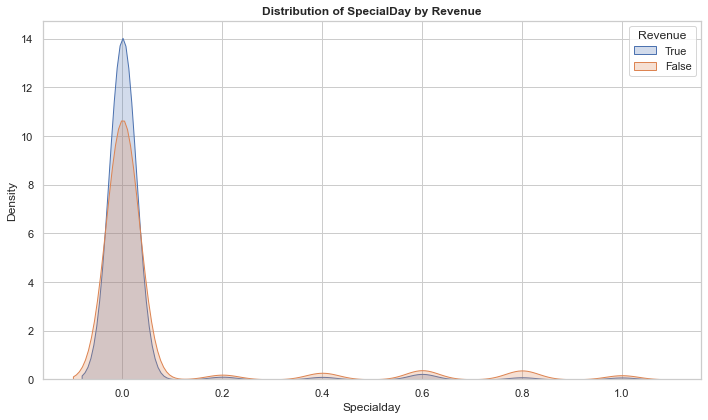

In [46]:
plot_stacked_bar_and_kde(df, 'SpecialDay', 'Revenue', plot=1)

**Intuition:** Most interactions or sessions occurred on non-special days. The data does not indicate a relationship between special days and revenue generation. This may be assumed as a notable finding, as people might expect higher revenue on special days, but the data does not support that hypothesis.

Text(0.5, 1.0, 'Effect of special days on the website')

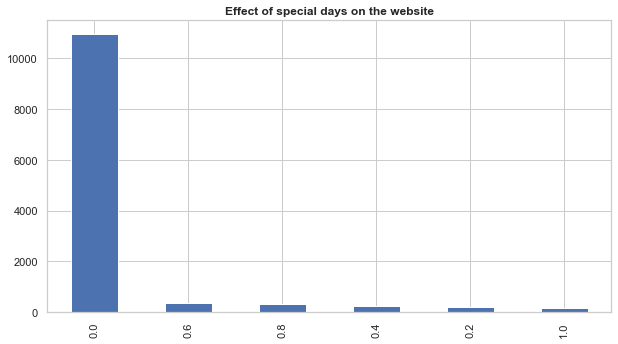

In [47]:
# Effect of special day on website
df.SpecialDay.value_counts().plot.bar(figsize=(9,5))
plt.title("Effect of special days on the website", fontweight='bold')

#### 2.4. Multivariate Analysis

**`BounceRates`** **vs.** **`ExistRates`**

**Hypothesis:** Higher bounce rates are expected to be positively correlated with higher exit rates in e-commerce, as both metrics reflect users leaving the site prematurely. Pages with high bounce rates likely indicate that users are not finding the desired information or content, leading to a higher likelihood of exiting the site altogether.\
**Intuition:** The scatterplot reveals a strong positive correlation between bounce rates and exit rates, as evidenced by the upward-sloping regression line. This trend indicates that as bounce rates increase, exit rates also tend to rise. Pages with low bounce rates exhibit relatively low exit rates, suggesting that these pages may successfully engage users, encouraging them to explore further. Conversely, high bounce rates correlate with higher exit rates, pointing to potential issues such as poor user experience, irrelevant content, or technical problems. This insight emphasizes the need to optimize pages with high bounce rates to improve user retention and reduce exits.

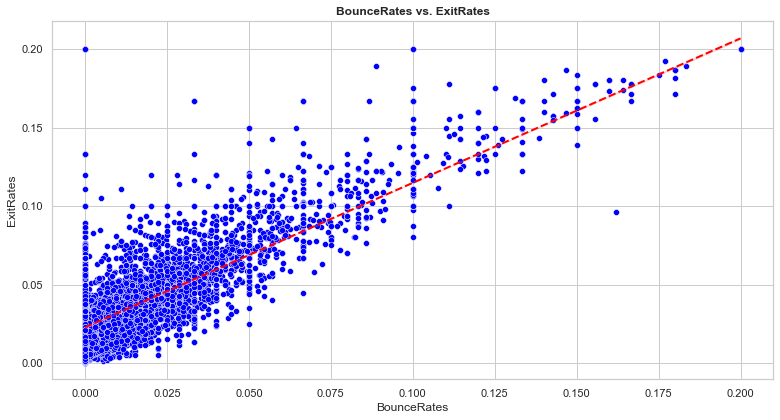

In [48]:
visualize_pair(df, "BounceRates", "ExitRates")

**`Number of pages visited`** **vs.** **`Duration`** **vs.** **`Revenue`**

**Intuition:** From the analysis of the percentage of pages visited, it becomes evident that customers primarily interact with ProductRelated pages, significantly more than Administrative and Informational pages. This observation suggests that users on the website are more interested in exploring products than engaging with administrative content (likely the homepage) or informational content (e.g., contact information). While the dataset does not explicitly define these categories, it is reasonable to infer that:

* **Administrative Pages** likely correspond to the homepage or other navigation-related content.
* **Informational Pages** may represent "Contact Us" or "Help" sections.
* **ProductRelated Pages** are focused on actual products that customers are exploring or intending to purchase.




In [49]:
# Number of pages visited: Administrative, Informational, ProductRelated
# Percentages of webpages visited

page_time_cols = ["Administrative_Duration","Informational_Duration","ProductRelated_Duration"]
page_count_cols = ["Administrative","Informational","ProductRelated"]
page_count = df[page_count_cols].groupby(df.Revenue).mean()
page_count

,Administrative,Informational,ProductRelated
Revenue,,,
False,2.143440,0.457318,29.050403
True,3.393606,0.786164,48.210168


* **High Focus on Product Pages:** The dominance of ProductRelated page interactions emphasizes the importance of optimizing product pages to maximize user engagement and conversions.
* **Potential Optimization Areas:** Administrative and Informational pages contribute marginally to the user's journey. These pages should be streamlined to provide essential navigation and support without distracting users from the product pages.

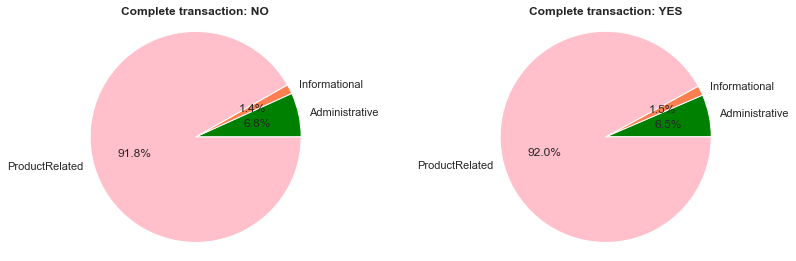

In [50]:
#People visit product related pages more rather than Admin or Informational which is obvious
#as user intends to purchase rather than just read admin and info pages on the website.
plt.figure(figsize=(12, 4))

plt.subplot(1,2,1)
plt.pie(page_count.iloc[0,:], labels = page_count.columns,
        autopct='%1.1f%%', shadow=False,
        colors=['green', 'coral', 'pink'])
plt.axis('equal')
plt.title('Complete transaction: NO', fontweight='bold')

plt.subplot(1,2,2)
plt.pie(page_count.iloc[1,:], labels = page_count.columns,
        autopct='%1.1f%%', shadow=False,
        colors=['green', 'coral', 'pink'])
plt.axis('equal')
plt.title('Complete transaction: YES', fontweight='bold')

plt.show()

**Multivariate Analyses 1:**

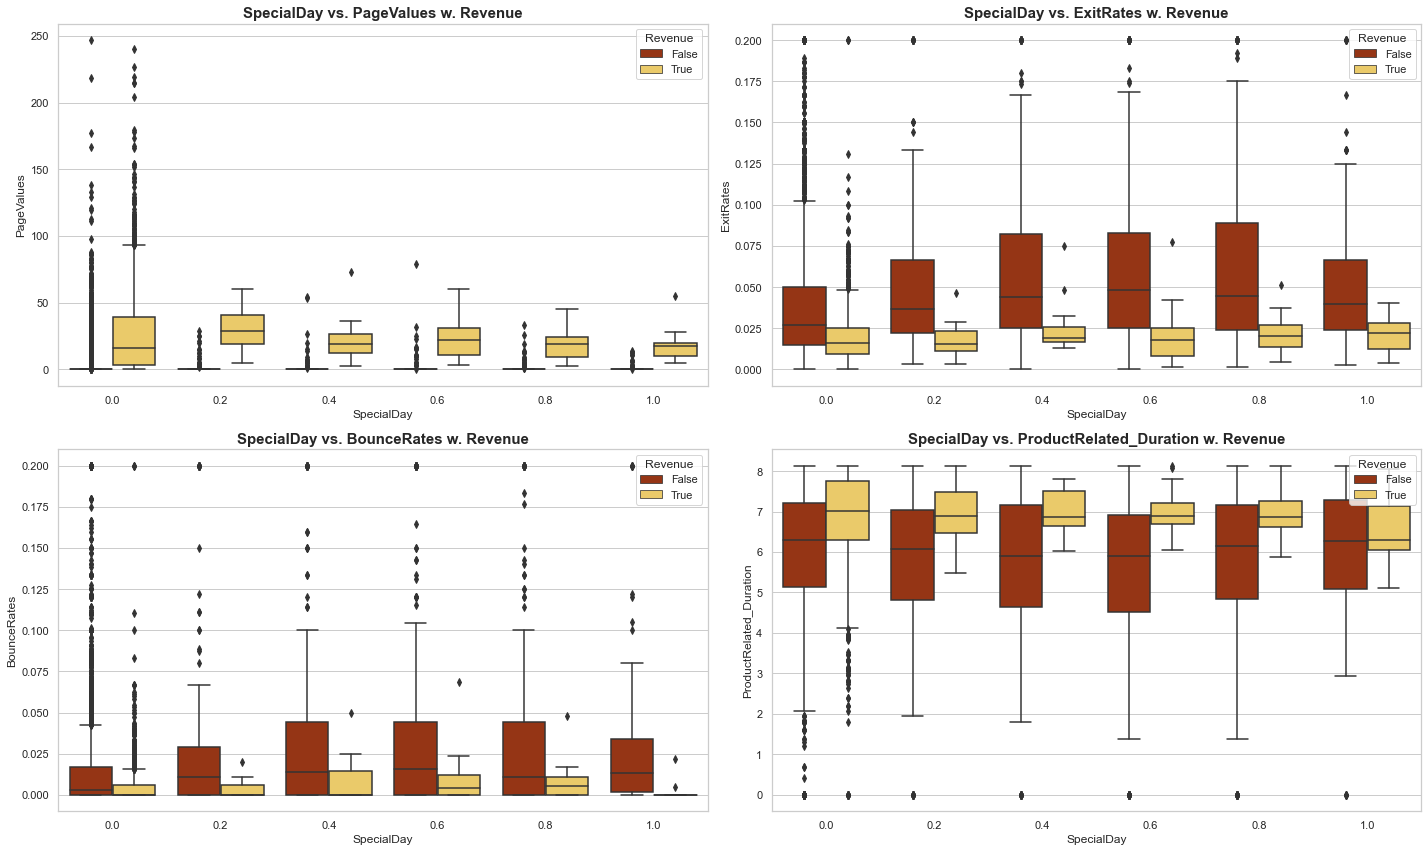

In [51]:
plt.rcParams['figure.figsize'] = (20, 12)

# SpecialDay vs. PageValues w. Revenue
plt.subplot(2, 2, 1)
sns.boxplot(x=df['SpecialDay'], y=df[df['PageValues'] < 250]['PageValues'], hue=df['Revenue'], palette='afmhot')
plt.title('SpecialDay vs. PageValues w. Revenue', fontsize=15, fontweight='bold')
plt.legend(title='Revenue', loc='upper right')

# SpecialDay vs. ExitRates w. Revenue
plt.subplot(2, 2, 2)
sns.boxplot(x=df['SpecialDay'], y=df['ExitRates'], hue=df['Revenue'], palette='afmhot')
plt.title('SpecialDay vs. ExitRates w. Revenue', fontsize=15, fontweight='bold')
plt.legend(title='Revenue', loc='upper right')

# SpecialDay vs. BounceRates w. Revenue
plt.subplot(2, 2, 3)
sns.boxplot(x=df['SpecialDay'], y=df['BounceRates'], hue=df['Revenue'], palette='afmhot')
plt.title('SpecialDay vs. BounceRates w. Revenue', fontsize=15, fontweight='bold')
plt.legend(title='Revenue', loc='upper right')

# SpecialDay vs. ProductRelated_Duration w. Revenue
plt.subplot(2, 2, 4)
sns.boxplot(x=df2['SpecialDay'], y=df2['ProductRelated_Duration'], hue=df2['Revenue'], palette='afmhot')
plt.title('SpecialDay vs. ProductRelated_Duration w. Revenue', fontsize=15, fontweight='bold')
plt.legend(title='Revenue', loc='upper right')

plt.tight_layout()
plt.show()

**Multivariate Analyses 2:**

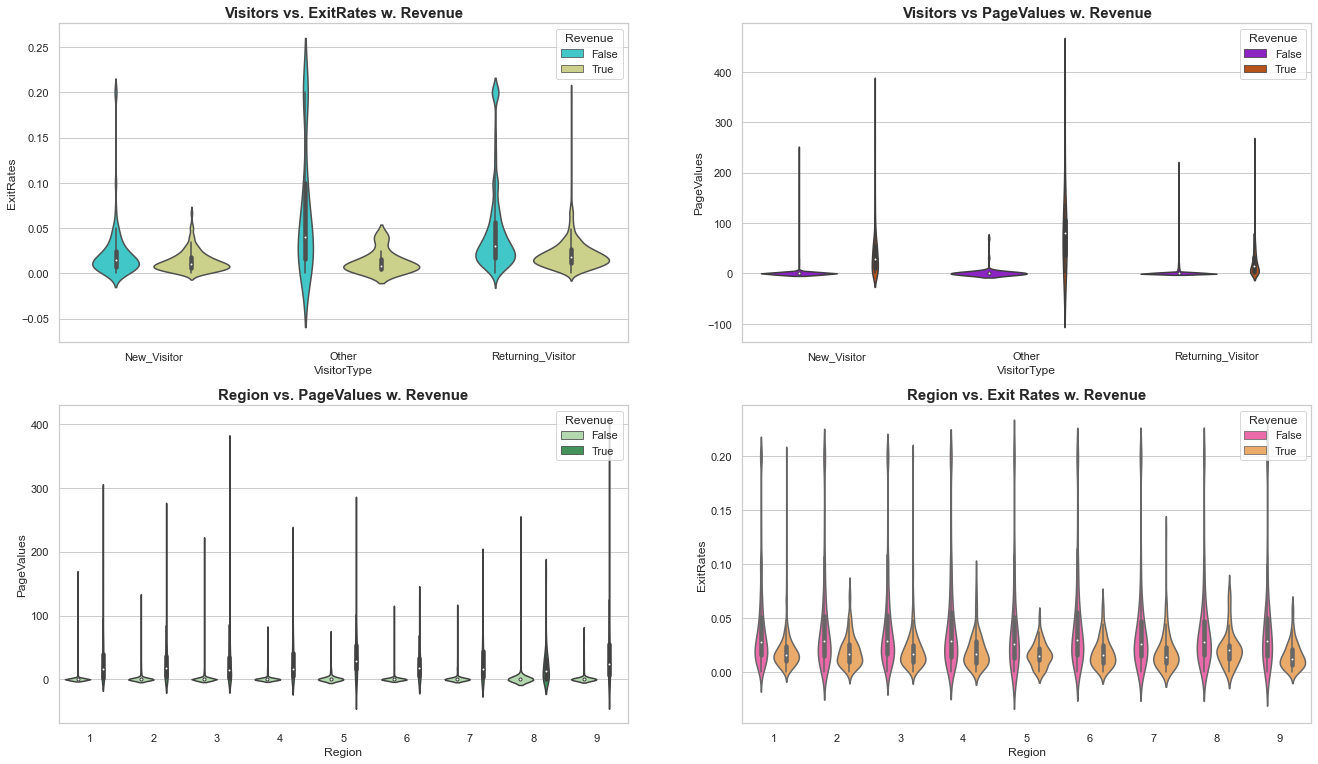

In [52]:
# Multivariate analysis 2
# Visitor type vs Exist Rates w. Revenue

plt.rcParams['figure.figsize'] = (20, 12)
plt.subplot(2, 2, 1)
sns.violinplot(x = df['VisitorType'], y = df['ExitRates'], hue = df['Revenue'], palette = 'rainbow')
plt.title('Visitors vs. ExitRates w. Revenue', fontsize=15, fontweight='bold')
plt.legend(title='Revenue', loc='upper right')

# Visitor type vs Page Values w. Revenue
plt.subplot(2, 2, 2)
sns.violinplot(x = df['VisitorType'], y = df['PageValues'], hue = df['Revenue'], palette = 'gnuplot')
plt.title('Visitors vs PageValues w. Revenue', fontsize=15, fontweight='bold')
plt.legend(title='Revenue', loc='upper right')

# Region vs Page Values w. Revenue
plt.subplot(2, 2, 3)
sns.violinplot(x = df['Region'], y = df['PageValues'], hue = df['Revenue'], palette = 'Greens')
plt.title('Region vs. PageValues w. Revenue', fontsize=15, fontweight='bold')
plt.legend(title='Revenue', loc='upper right')

# Region vs Exist Rates w. Revenue
plt.subplot(2, 2, 4)
sns.violinplot(x = df['Region'], y = df['ExitRates'], hue = df['Revenue'], palette = 'spring')
plt.title('Region vs. Exit Rates w. Revenue', fontsize=15, fontweight='bold')
plt.legend(title='Revenue', loc='upper right')

plt.show()

#### 2.5. Pairwise Plot

**Intuition:** The pairwise plot highlights relationships between various attributes and the Revenue as follows:

* There is a positive correlation between the number of **`ProductRelated pages`** visited and **`ProductRelated_Duration`**, in which users with higher engagement in these pages are more likely to complete a transaction.
* Lower **`BounceRates`** and **`ExitRates`** are associated with completed transactions, suggesting better engagement with the website.
* **`Administrative`** and **`informational pages`** have minimal influence on revenue, suggesting a focus on optimizing product pages and engagement metrics.
*   Higher **`PageValues`** are strongly associated with completed transactions, this metric could serve as a predictive factor, indicating the likelihood of purchase.
* A negative relationship exists between **`BounceRates`** and **`PageValues`**. Higher PageValues are associated with lower BounceRates, which is intuitive since engaging content reduces user drop-off rates. For transactions (Revenue=1), this pattern is particularly prominent, *suggesting that bounce rates are a key metric for identifying and improving conversion potential.*
* A positive relationship between the number of **`ProductRelated pages`** visited and **`SpecialDay`** indicates that users tend to explore more products during special promotional periods.




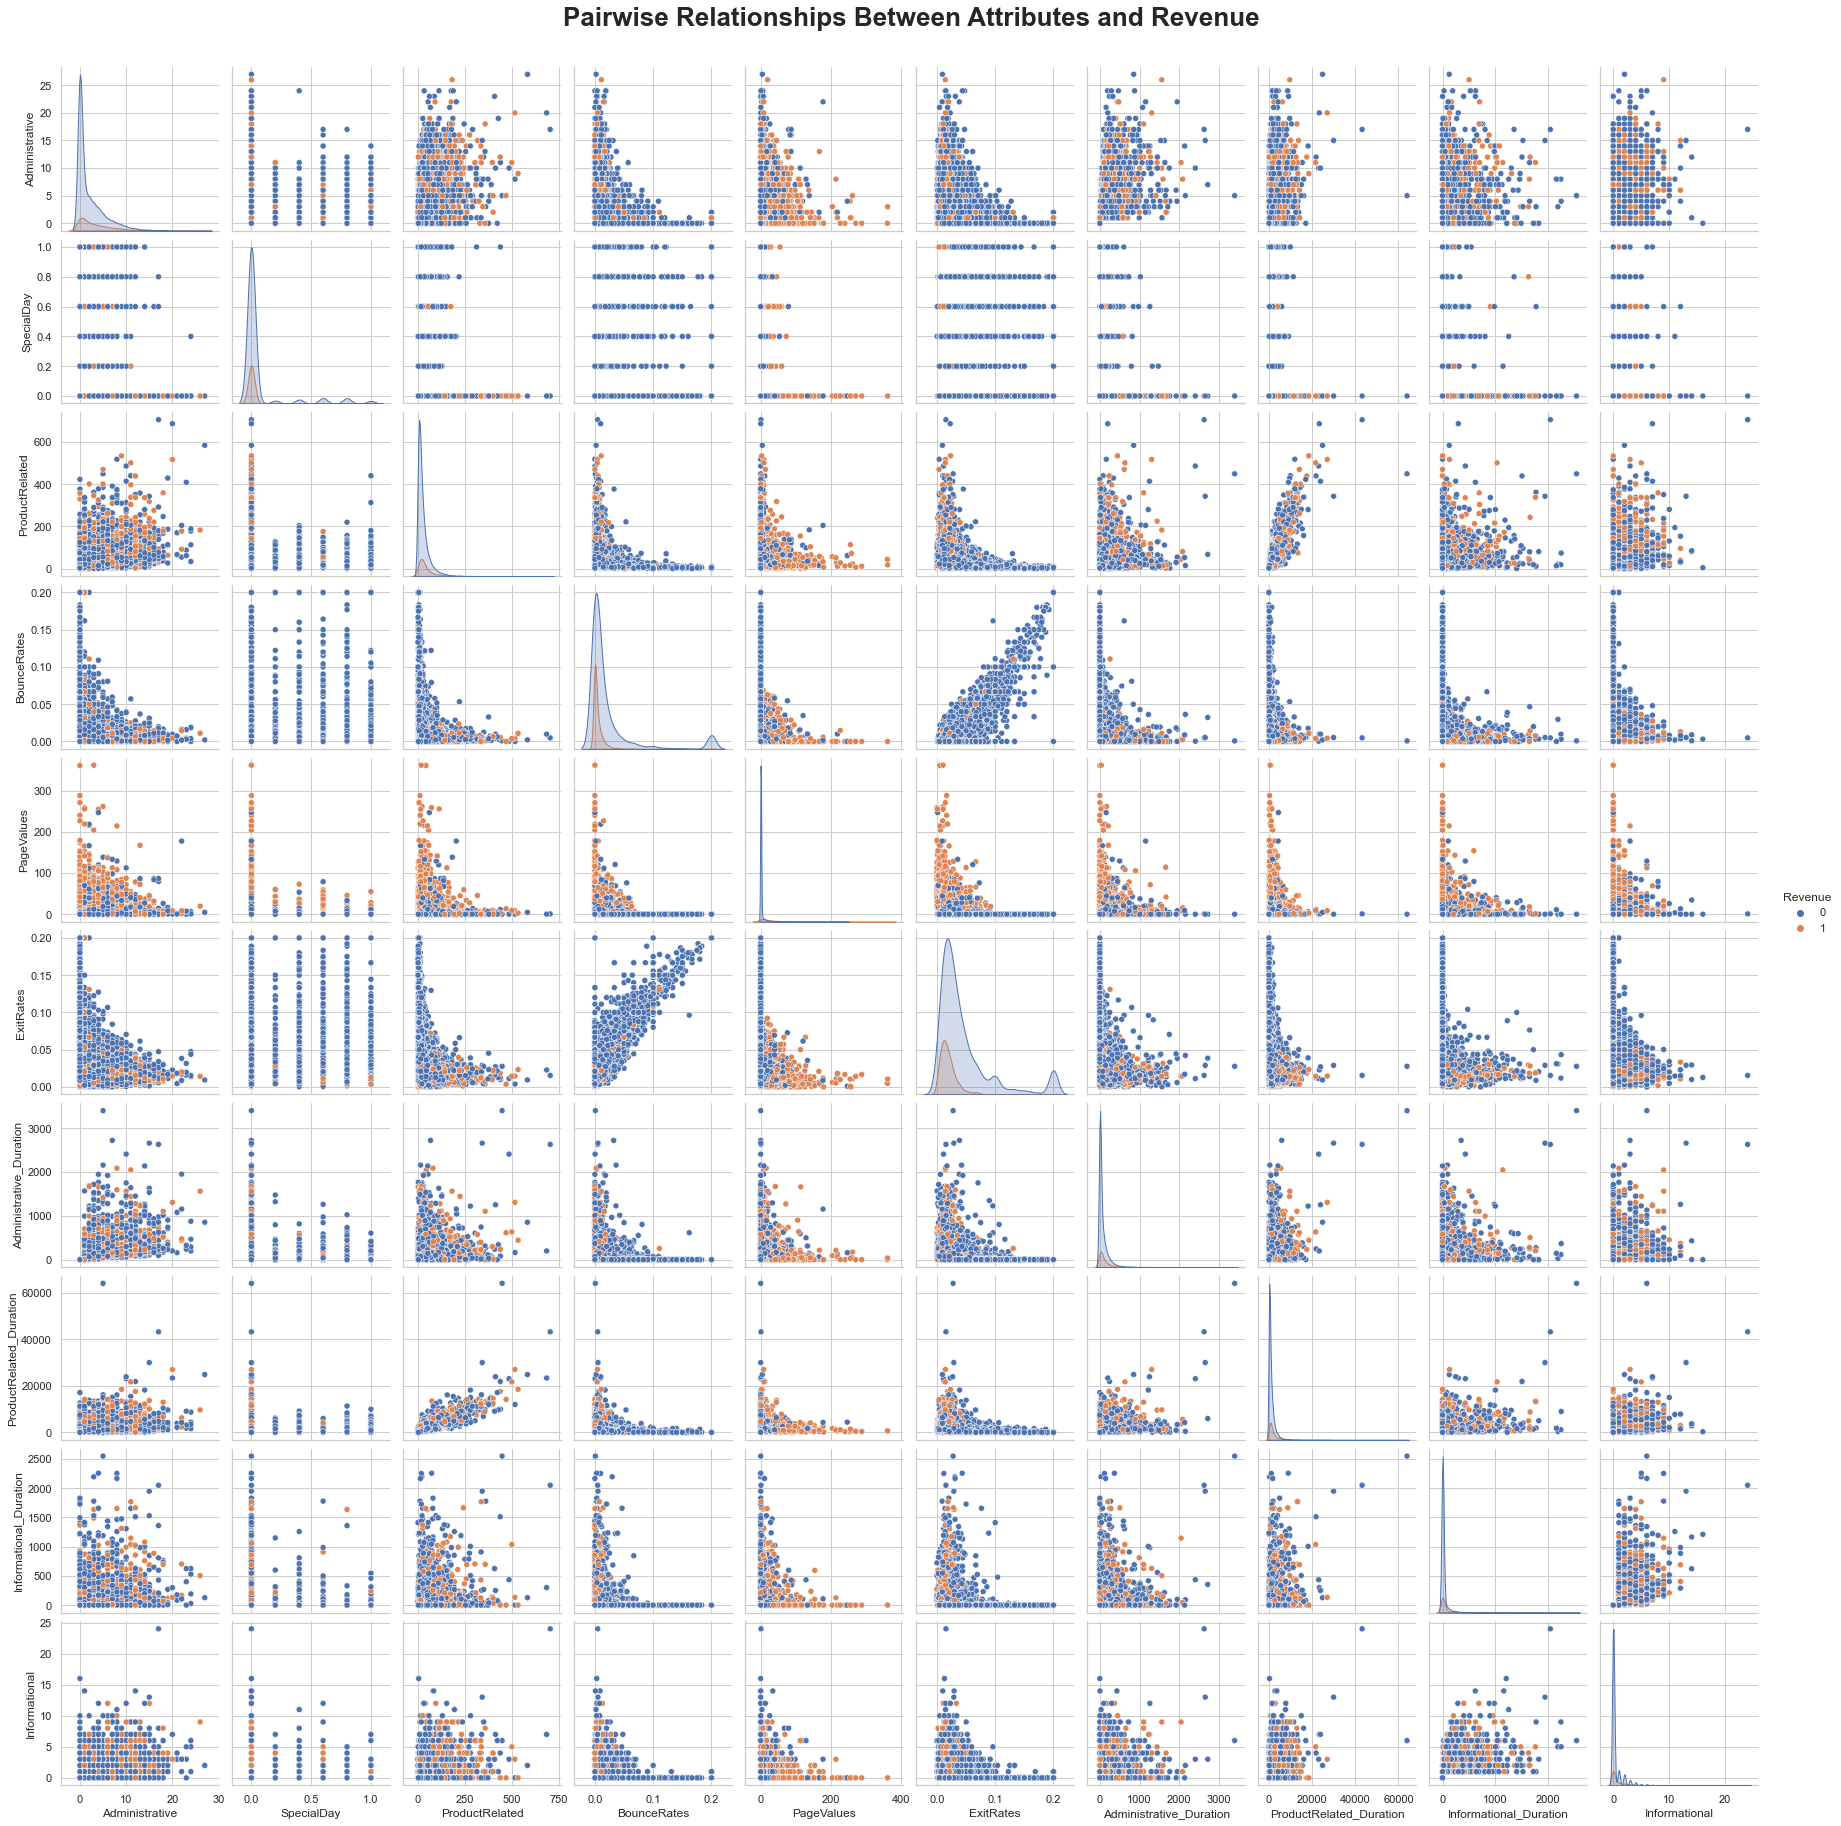

In [53]:
df_pairwise = df.copy()
df_pairwise['Revenue'] = df_pairwise['Revenue'].astype(int)

pairwise_vars = ['Administrative', 'SpecialDay', 'ProductRelated', 'BounceRates',
                 'PageValues', 'ExitRates', 'Administrative_Duration', 'ProductRelated_Duration', 'Informational_Duration', 'Informational', 'Revenue']

# Create the pairplot
sns.pairplot(
    df_pairwise[pairwise_vars],
    hue='Revenue',
    diag_kind='kde',
    plot_kws={'alpha': 1},
    diag_kws={'fill': True}
)
plt.suptitle('Pairwise Relationships Between Attributes and Revenue',
             fontsize=26, fontweight='bold', y=1.02)
plt.show()

# Step 3: Feature Selection

### 1. Preprocessing

##### One-hot & Label Encoding

In [54]:
# One-hot encoding of categorical variables
# Create list with features to be dummified cols.
nonum_feats_names = ['Month','OperatingSystems','Browser','Region','VisitorType','Weekend']
dataModel = pd.concat([df2[['Administrative', 'Administrative_Duration', 'Informational','Informational_Duration',
                            'ProductRelated','ProductRelated_Duration','BounceRates','ExitRates','PageValues', 'TrafficType','SpecialDay']],
                       pd.get_dummies(df2[nonum_feats_names].astype('category')), df2['Revenue']],axis=1)

dataModel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12205 entries, 0 to 12204
Data columns (total 57 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   Administrative                 12205 non-null  int64   
 1   Administrative_Duration        12205 non-null  float64 
 2   Informational                  12205 non-null  int64   
 3   Informational_Duration         12205 non-null  float64 
 4   ProductRelated                 12205 non-null  int64   
 5   ProductRelated_Duration        12205 non-null  float64 
 6   BounceRates                    12205 non-null  float64 
 7   ExitRates                      12205 non-null  float64 
 8   PageValues                     12205 non-null  float64 
 9   TrafficType                    12205 non-null  category
 10  SpecialDay                     12205 non-null  float64 
 11  Month_Aug                      12205 non-null  uint8   
 12  Month_Dec                      1

In [55]:
# Label Encoding of Revenue
le = LabelEncoder()
dataModel['Revenue'] = le.fit_transform(dataModel['Revenue'])
dataModel['Revenue'].value_counts()

0    10297
1     1908
Name: Revenue, dtype: int64

##### StandardScalar

In [56]:
# Getting dependent and independent variables
X = dataModel
# removing the target column revenue from x
X = X.drop(['Revenue'], axis = 1)
y = dataModel['Revenue']

# splitting the data
X_baseTrain, X_baseTest, y_baseTrain, y_baseTest = train_test_split(X, y, test_size = 0.3, random_state = 42, shuffle=True, stratify=y)

# checking the shapes
print("Shape of X_train :", X_baseTrain.shape)
print("Shape of y_train :", y_baseTrain.shape)
print("Shape of X_test :", X_baseTest.shape)
print("Shape of y_test :", y_baseTest.shape)

Shape of X_train : (8543, 56)
Shape of y_train : (8543,)
Shape of X_test : (3662, 56)
Shape of y_test : (3662,)


**Approach:** Scaling the data first fitting it and transforming the training set to later apply the fit to transform the test set, to reduce overfitting.


In [57]:
# SCALING WITH STANDARD Z SCORE SCALER
num_cols_names = ['Administrative', 'Administrative_Duration', 'Informational','Informational_Duration',
                  'ProductRelated','ProductRelated_Duration','BounceRates','ExitRates','PageValues','TrafficType','SpecialDay']

#Instantiate Satandard Scaler
scaler = StandardScaler()

#Fit transform the numerical features in the training dataset to a new dataframe
scaled_numfeats_train = pd.DataFrame(scaler.fit_transform(X_baseTrain[num_cols_names]),
                                     columns=num_cols_names, index= X_baseTrain.index)

#Integrate scaled values to the training set
for col in num_cols_names:
    X_baseTrain[col] = scaled_numfeats_train[col]

# Transform the numerical features in the training dataset to a new dataframe
scaled_numfeats_test = pd.DataFrame(scaler.transform(X_baseTest[num_cols_names]),
                                    columns=num_cols_names, index= X_baseTest.index)

# Integrate scaled values to the test set
for col in num_cols_names:
    X_baseTest[col] = scaled_numfeats_test[col]

In [58]:
# Duplicate the X_train and X_test, Y_train and Y_test to keep the original data
x_baseTrain_original = X_baseTrain.copy()
x_baseTest_original = X_baseTest.copy()
y_baseTrain_original = y_baseTrain.copy()
y_baseTest_original = y_baseTest.copy()

### 2. Feature Selection

After encoding, we are left with approximately 50 features, which is excessive for our models to handle efficiently. Additionally, some of these features may be redundant and could negatively impact model accuracy. Therefore, feature selection becomes a crucial step as it enables models to train more quickly, reduces model complexity, minimizes overfitting, and enhances accuracy.

There are many techniques to select most relevant features:
+ 1. Correlation Exploration
+ 2. Information Gain (Mutual information & SelectKBest)
+ 3. Fisher Score (Cat Variables)
+ 4. Inivariate ROC_AUC
+ 5. Random Forest feature importance

#### 1. Correlation Exploration

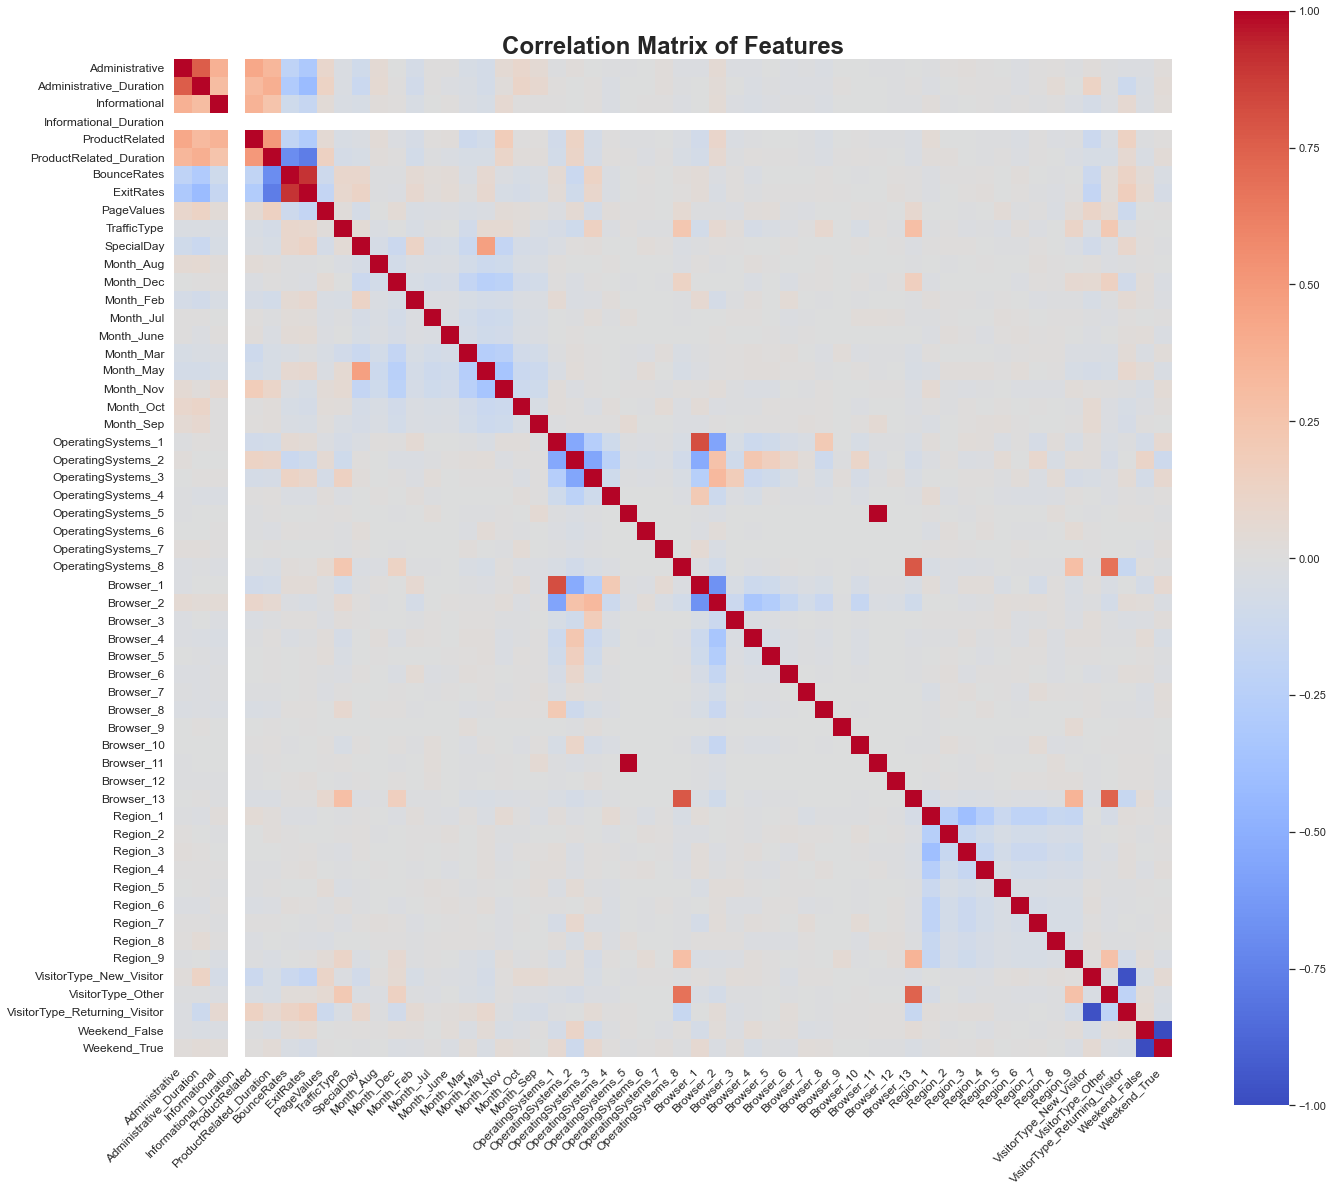

In [59]:
# Pearson correlation for numerical variables
numerical_corr = X_baseTrain.corr(method='pearson')

# Visualize Pearson Correlation
plt.figure(figsize=(20, 20))  # Increase the figure size
sns.heatmap(
    numerical_corr,
    annot=False,  # Turn off annotations for clarity (set to True if needed)
    cmap='coolwarm',
    fmt='.2f',
    center=0,
    square=True,  # Square cells for better alignment
    cbar_kws={'shrink': 0.8}  # Shrink the color bar
)

# Rotate x-axis and y-axis labels
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)

# Add title
plt.title('Correlation Matrix of Features', fontsize=24, fontweight='bold')

# Show plot
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

**Intuition:** We observe that there are 8 combo features are highly correlated with each others. By removing correlated features and only keeping representative one will help simplify our model without sacrificing much predictive power.

In [60]:
# With the following function we can select highly correlated features
# It will remove the first feature that is correlated with anything else without any other insight.

corrmat = X_baseTrain.corr()
corrmat = corrmat.abs().unstack() # absolute value of corr coef
corrmat = corrmat.sort_values(ascending=False)
corrmat = corrmat[corrmat >= 0.8]
corrmat = corrmat[corrmat < 1]
corrmat = pd.DataFrame(corrmat).reset_index()
corrmat.columns = ['Feature1', 'Feature2', 'corr']
corrmat

,Feature1,Feature2,corr
0,Weekend_True,Weekend_False,1.000000
1,Weekend_False,Weekend_True,1.000000
2,VisitorType_Returning_Visitor,VisitorType_New_Visitor,0.970706
3,VisitorType_New_Visitor,VisitorType_Returning_Visitor,0.970706
4,ExitRates,BounceRates,0.899886
5,BounceRates,ExitRates,0.899886
6,Browser_1,OperatingSystems_1,0.812784
7,OperatingSystems_1,Browser_1,0.812784


**Insight:** Looking at the Correlation & "Features vs. Target analysis", we will take a decision here to drop **`Browser_1`**, **`BounceRates`**, **`Product_Related`** and **`VisitorType_Returning_Visitor.`**

In [61]:
X_baseTrain.drop(labels=['Weekend_True', 'Browser_1', 'BounceRates', 'VisitorType_Returning_Visitor'], axis=1, inplace=True)
X_baseTest.drop(labels=['Weekend_True', 'Browser_1', 'BounceRates', 'VisitorType_Returning_Visitor'], axis=1, inplace=True)

X_baseTrain.shape, X_baseTest.shape

((8543, 52), (3662, 52))

#### 2. Mutual Infomation and SelectKBest

One of the key techniques applied for feature selection in this analysis is **Mutual Information (MI)** combined with **SelectKBest**.

+ **Mutual Information:** Measures the dependency between features and the target variable. Features with higher MI values share more information with the target, making them more relevant for prediction (left of the plot).
+ **SelectKBest:** A method to select the top k features based on their MI scores, helping reduce dimensionality and focus on the most important variables.


In [62]:
X_baseTrain2 = X_baseTrain.copy()
y_baseTrain2 = y_baseTrain.copy()

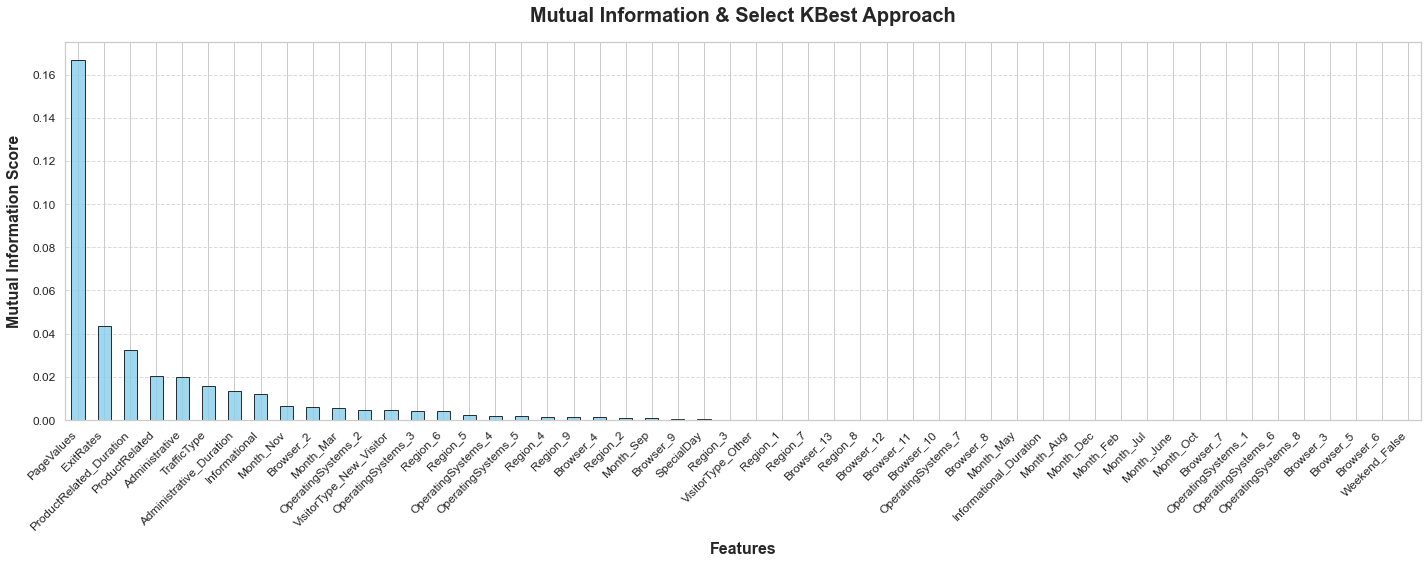

In [63]:
# Calculate the mutual information between the variables and the target
# Smaller values indicate less information about the target
mi = mutual_info_classif(X_baseTrain2, y_baseTrain2)

# Convert mutual information values to a pandas Series for better manipulation
mi = pd.Series(mi, index=X_baseTrain2.columns)

# Sort mutual information in descending order for visualization
mi_sorted = mi.sort_values(ascending=False)

# Create a bar plot
plt.figure(figsize=(20, 8))
ax = mi_sorted.plot.bar(color='skyblue', edgecolor='black', alpha=0.8)

# Add plot title and labels
ax.set_title('Mutual Information & Select KBest Approach', fontsize=20, fontweight='bold', pad=20)
ax.set_xlabel('Features', fontsize=16, fontweight='bold', labelpad=10)
ax.set_ylabel('Mutual Information Score', fontsize=16, fontweight='bold', labelpad=10)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Add gridlines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust plot layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

In [64]:
# Select the top 25 features by using SelectKBest
sel_ = SelectKBest(mutual_info_classif, k=25).fit(X_baseTrain2, y_baseTrain2)
print("Selected features:")
X_baseTrain2.columns[sel_.get_support()]

Selected features:


Index(['Administrative', 'Administrative_Duration', 'Informational',
       'ProductRelated', 'ProductRelated_Duration', 'ExitRates', 'PageValues',
       'TrafficType', 'SpecialDay', 'Month_Feb', 'Month_May', 'Month_Nov',
       'Month_Oct', 'OperatingSystems_2', 'OperatingSystems_3',
       'OperatingSystems_6', 'Browser_2', 'Browser_7', 'Browser_8',
       'Browser_10', 'Browser_11', 'Region_3', 'Region_8', 'Region_9',
       'VisitorType_New_Visitor'],
      dtype='object')

#### 3. Chi-Square


Another feature selection technique used is the **Chi-Square (Chi²)**.

+ **Chi-Square Test:** This statistical test evaluates the independence between categorical features and the target variable. It calculates the significance (p-value) of each feature in predicting the target.

+ **P-Value Interpretation:** Features with smaller p-values (e.g., ≤ 0.05) are considered statistically significant and more relevant for predicting the target variable.

To implement this, categorical variables are scaled using MinMaxScaler to transform their values into the range [0, 1], ensuring compatibility with the Chi² test.

In [65]:
X_baseTrain3 = X_baseTrain.copy()
y_baseTrain3 = y_baseTrain.copy()

In [66]:
scaler = MinMaxScaler()
X_baseTrain3_scaled = scaler.fit_transform(X_baseTrain3)

# calculate the chi2 p_value between each of the cat variables and the target
f_score = chi2(X_baseTrain3_scaled, y_baseTrain3)

pvalues = pd.Series(f_score[1])
pvalues.index = X_baseTrain3.columns

In [67]:
# Set the p-value threshold
threshold = 0.05

# Filter features with p-values <= threshold
selected_features = pvalues[pvalues <= threshold].index

print("Selected features:")
print(selected_features)

Selected features:
Index(['Administrative', 'Administrative_Duration', 'Informational',
       'ProductRelated', 'ProductRelated_Duration', 'ExitRates', 'PageValues',
       'SpecialDay', 'Month_Feb', 'Month_June', 'Month_Mar', 'Month_May',
       'Month_Nov', 'Month_Oct', 'OperatingSystems_2', 'OperatingSystems_3',
       'Browser_3', 'Browser_7', 'Browser_13', 'VisitorType_New_Visitor'],
      dtype='object')


#### 4. Univariate ROC_AUC

Another technique to consider is **ROC-AUC** for Feature Selection:
+ ROC-AUC evaluates the discriminatory power of each feature independently, without relying on specific model assumptions.
+ It performs well even when the dataset is imbalanced.
+ Captures Non-linear Relationships: By leveraging decision trees, this method is capable of detecting non-linear patterns between features and the target variable, enhancing its effectiveness

In [68]:
X_baseTrain4 = X_baseTrain.copy()
y_baseTrain4 = y_baseTrain.copy()
X_baseTest4 = X_baseTest.copy()
y_baseTest4 = y_baseTest.copy()

In [69]:
# Calculate ROC-AUC values for each feature
roc_values = []
for feature in X_baseTrain4.columns:
    clf = DecisionTreeClassifier()  # Initialize a Decision Tree Classifier
    clf.fit(X_baseTrain4[feature].to_frame(), y_baseTrain4)  # Train on a single feature
    y_scored = clf.predict_proba(X_baseTest4[feature].to_frame())[:, 1]  # Predict probabilities
    roc_values.append(roc_auc_score(y_baseTest4, y_scored))  # Calculate ROC-AUC

# Convert ROC-AUC values to a pandas Series for better handling
roc_values = pd.Series(roc_values, index=X_baseTrain4.columns)

# Sort ROC-AUC values in descending order for visualization
roc_values_sorted = roc_values.sort_values(ascending=False)

# Print retained and removed features based on threshold (0.5)
print("Features to Retain (ROC-AUC > 0.5):")
print(roc_values_sorted[roc_values_sorted > 0.5])

print("\nFeatures to Remove (ROC-AUC ≤ 0.5):")
print(roc_values_sorted[roc_values_sorted <= 0.5])

Features to Retain (ROC-AUC > 0.5):
Administrative             0.619363
TrafficType                0.613909
ProductRelated             0.611505
Month_Nov                  0.602867
Informational              0.576495
PageValues                 0.573253
VisitorType_New_Visitor    0.560145
ExitRates                  0.550174
Month_May                  0.541256
OperatingSystems_2         0.540180
ProductRelated_Duration    0.538695
OperatingSystems_3         0.537125
Month_Mar                  0.533089
SpecialDay                 0.532158
Month_Dec                  0.529368
Administrative_Duration    0.518324
Region_1                   0.514057
Weekend_False              0.513578
Region_6                   0.510928
Month_Feb                  0.506893
Browser_2                  0.506544
Browser_5                  0.506254
Browser_4                  0.505095
Region_8                   0.504396
Month_Sep                  0.504054
OperatingSystems_1         0.504003
Month_June                 0

**Intuition:** 41 of 56 features show a predictive performance higher than 0.5. This means that we could remove 15 features from this dataset using this method.

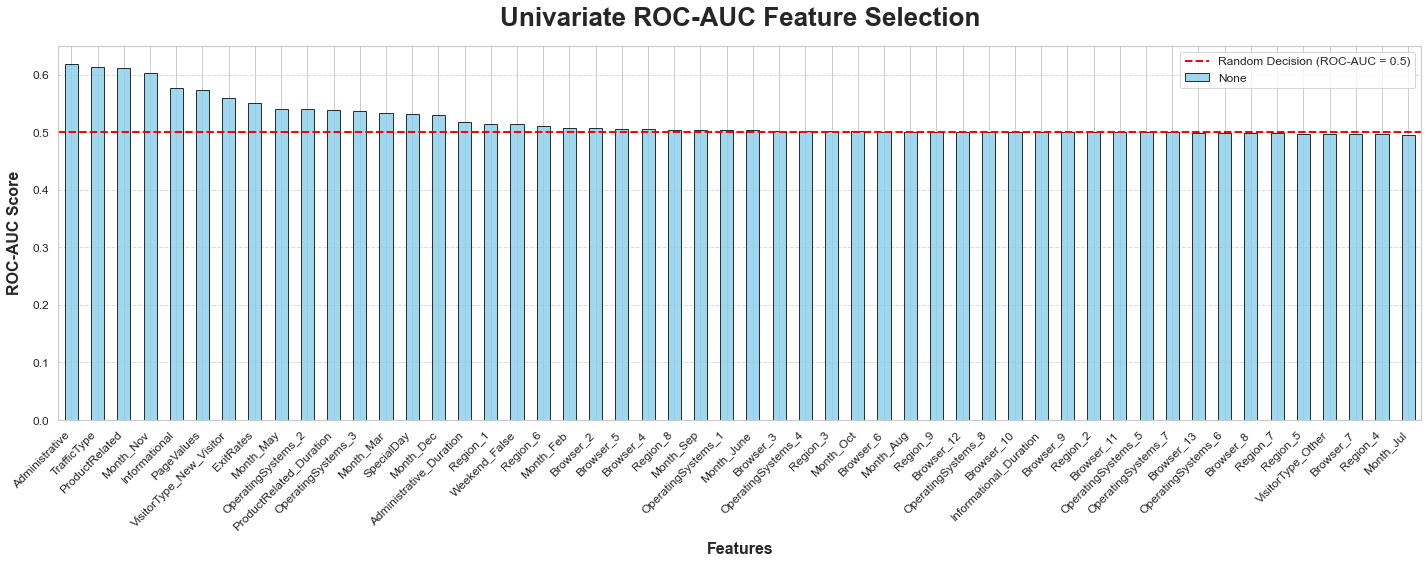

In [70]:
# Plot the ROC-AUC values
plt.figure(figsize=(20, 8))
ax = roc_values_sorted.plot.bar(color='skyblue', edgecolor='black', alpha=0.8)

# Add title and labels
ax.set_title('Univariate ROC-AUC Feature Selection', fontsize=26, fontweight='bold', pad=20)
ax.set_xlabel('Features', fontsize=16, fontweight='bold', labelpad=10)
ax.set_ylabel('ROC-AUC Score', fontsize=16, fontweight='bold', labelpad=10)

# Highlight threshold line
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Random Decision (ROC-AUC = 0.5)')
plt.legend(fontsize=12)

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Add gridlines
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

#### 5. Random Forest Recursive Feature Eliminaton (RFE)

**Random Forest Recursive Feature Elimination (RFE)** is a wrapper-based feature selection method that combines model fitting and feature elimination into one iterative process:

+ At each iteration, the least important feature is removed based on feature importance scores provided by the model (in this case, a Random Forest Classifier).
+ After each removal, the model is re-fitted to the remaining features.
+ The process continues until a pre-defined number of features is reached.

In this example, we set **`n_features_to_select=25`**, indicating that we aim to select the top 25 most important features. This method helps reduce dimensionality and noise while retaining features that are highly predictive of the target variable.


In [71]:
X_baseTrain5 = X_baseTrain.copy()
X_baseTest5 = X_baseTest.copy()
y_baseTrain5 = y_baseTrain.copy()
y_baseTest5 = y_baseTest.copy()

In [72]:
sel2_ = RFE(RandomForestClassifier(n_estimators=100), n_features_to_select=25)
sel2_.fit(X_baseTrain5, y_baseTrain5)

RFE(estimator=RandomForestClassifier(), n_features_to_select=25)

In [73]:
# Get the selected feature names
selected_featCorrRFE = X_baseTrain5.columns[sel2_.get_support()]

# Print the number of selected features
print(f"Number of selected features: {len(selected_featCorrRFE)}")

# Display the list of selected features
print("Selected Features:")
print(selected_featCorrRFE)

Number of selected features: 25
Selected Features:
Index(['Administrative', 'Administrative_Duration', 'Informational',
       'ProductRelated', 'ProductRelated_Duration', 'ExitRates', 'PageValues',
       'TrafficType', 'Month_Dec', 'Month_Mar', 'Month_May', 'Month_Nov',
       'Month_Oct', 'Month_Sep', 'OperatingSystems_1', 'OperatingSystems_2',
       'OperatingSystems_3', 'Browser_2', 'Browser_4', 'Region_1', 'Region_2',
       'Region_3', 'Region_4', 'VisitorType_New_Visitor', 'Weekend_False'],
      dtype='object')


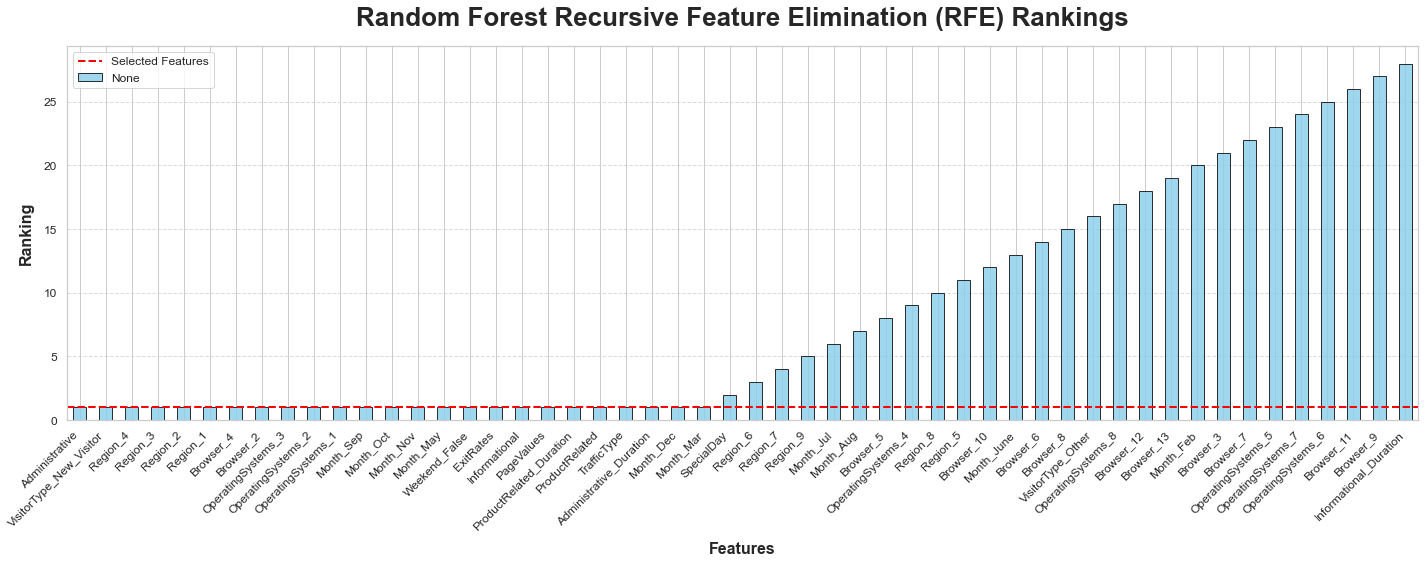

In [74]:
# Plot feature rankings
ranking = sel2_.ranking_
ranking_df = pd.Series(ranking, index=X_baseTrain5.columns).sort_values()

# Visualize feature rankings
plt.figure(figsize=(20, 8))
ax = ranking_df.plot.bar(color='skyblue', edgecolor='black', alpha=0.8)

# Add title and labels
ax.set_title('Random Forest Recursive Feature Elimination (RFE) Rankings', fontsize=26, fontweight='bold', pad=20)
ax.set_xlabel('Features', fontsize=16, fontweight='bold', labelpad=10)
ax.set_ylabel('Ranking', fontsize=16, fontweight='bold', labelpad=10)

# Highlight top features
plt.axhline(y=1, color='red', linestyle='--', linewidth=2, label='Selected Features')
plt.legend(fontsize=12)

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Add gridlines
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

# Step 4: Modelling Approach

To recap, this project aims to develop classification and regression models to analyze the dataset.
+ **For classification**, predict whether a user makes a purchase (purchased or not purchased) using the top features identified through Feature Selection and Feature vs. Target Analysis.

➜ Build and evaluate classification models, with a focus on Random Forest and Stacking Models.
The stacking model integrates multiple algorithms (e.g., XGBoost, Decision Tree) to improve prediction accuracy and robustness.

+ **For clustering**, increase purchase rates by targeting user segments with promising behavioral patterns and optimizing their website experience. Furthermore, identify "untapped potential" groups, such as users who view multiple products but leave without converting to set targeted strategies.

**Top Features to select for Classification Problem based on the analysis above:**

| **Features to Select**  | **Mutual Information & SelectKBest** | **Chi-Square** | **ROC-AUC** | **Random Forest RFE** |
|:------------------:|:------------------------------------:|:--------------:|:-----------:|:----------------------:|
| **Administrative**          | x | x | x | x |
| **Administrative_Duration** | x | x | x | x |
| **Informational**           | x | x | x | x |
| **ProductRelated**          | x |   |   |   |
| **ProductRelated_Duration** | x |   | x | x |
| **ExitRates**  |x | x | x | x |
| **PageValues** |x | x | x | x |
| **TrafficType**|x |   | x | x |
| **SpecialDay** |x | x | x |   |
| **Month_Feb**  |x | x | x |   |
| **Month_Mar**  |x | x | x | x |
| **Month_May**  |x | x | x | x |
| **Month_June** |x | x | x |   |
| **Month_Oct**  |x | x | x |   |
| **Month_Nov**  |x | x | x | x |
| **Month_Dec**  |x |   | x | x |
| **Browser_2**  |x |   | x | x |
| **Browser_4**  |  |   | x | x |
| **Region_1**   |  |   | x | x |
| **Region_3**   |  |   | x | x |
| **OperatingSystems_2**  |x | x|x|x |
| **OperatingSystems_3**  |x | x|x|x |
| **OperatingSystems_8**  |x |  |x|  |
| **VisitorType_New_Visitor** |x | x | x | x |
| **Weekend_False**        |x |  |x|x|

In [75]:
X_Train = X_baseTrain[['PageValues'
                            ,'Month_Feb','Month_Mar','Month_May','Month_June','Month_Oct','Month_Nov','Month_Dec'
                            ,'Browser_2','Browser_4'
                            ,'Region_1','Region_3'
                            ,'OperatingSystems_2','OperatingSystems_3','OperatingSystems_8'
                            ,'ProductRelated','ProductRelated_Duration'
                            ,'ExitRates'
                            ,'TrafficType'
                            ,'Administrative_Duration','Administrative'
                            ,'Informational_Duration'
                            ,'VisitorType_New_Visitor'
                            ,'Weekend_False'
                            ,'SpecialDay']]

X_Test = X_baseTest[['PageValues'
                            ,'Month_Feb','Month_Mar','Month_May','Month_June','Month_Oct','Month_Nov','Month_Dec'
                            ,'Browser_2','Browser_4'
                            ,'Region_1','Region_3'
                            ,'OperatingSystems_2','OperatingSystems_3','OperatingSystems_8'
                            ,'ProductRelated','ProductRelated_Duration'
                            ,'ExitRates'
                            ,'TrafficType'
                            ,'Administrative_Duration','Administrative'
                            ,'Informational_Duration'
                            ,'VisitorType_New_Visitor'
                            ,'Weekend_False'
                            ,'SpecialDay']]

print(X_Train.shape, X_Test.shape)

(8543, 25) (3662, 25)


In [76]:
y_Train = y_baseTrain.copy()
y_Test = y_baseTest.copy()

### Handling imbalance class - Oversampling and Undersampling using SMOTEEN

Imbalanced datasets often lead to biased models that perform poorly on minority classes. Therefore, we will combine Oversampling and Undersampling to handle severe imbalanced **`Revenue`**.

**Intuition:** The sampling strategy is set to 0.35, meaning the minority class will be oversampled to 35% of the majority class. The Edited Nearest Neighbours (ENN) component ensures that noisy majority class samples are removed, resulting in a cleaner and more balanced dataset.



In [77]:
sm = SMOTEENN(random_state=33, sampling_strategy=0.35, enn=EditedNearestNeighbours(sampling_strategy='majority'))
X_Train_res, y_Train_res = sm.fit_resample(X_Train, y_Train)

In [78]:
print("Shape of x_train :", X_Train_res.shape)
print("Shape of y_train :", y_Train_res.shape)

Shape of x_train : (8106, 25)
Shape of y_train : (8106,)


In [79]:
print("Before handling imbalance Class:")
print(pd.DataFrame(y_baseTrain,columns=['Revenue']).Revenue.value_counts(normalize=True))
print(Counter(y_baseTrain))

Before handling imbalance Class:
0    0.843615
1    0.156385
Name: Revenue, dtype: float64
Counter({0: 7207, 1: 1336})


In [80]:
print("After handling imbalance Class by applying Oversampling & Undersampling:")
print(pd.DataFrame(y_Train_res,columns=['Revenue']).Revenue.value_counts(normalize=True))
print(Counter(y_Train_res))

After handling imbalance Class by applying Oversampling & Undersampling:
0    0.688872
1    0.311128
Name: Revenue, dtype: float64
Counter({0: 5584, 1: 2522})


## 4.1 Classification Models

### Logistic Regression

Model accuracy for train set: 0.908
Model accuracy for test set: 0.871

              precision    recall  f1-score   support

           0       0.95      0.90      0.92      3090
           1       0.57      0.73      0.64       572

    accuracy                           0.87      3662
   macro avg       0.76      0.81      0.78      3662
weighted avg       0.89      0.87      0.88      3662


Confusion Matrix:
 [[2773  317]
 [ 155  417]]

Accuracy Score:  0.8711086837793556


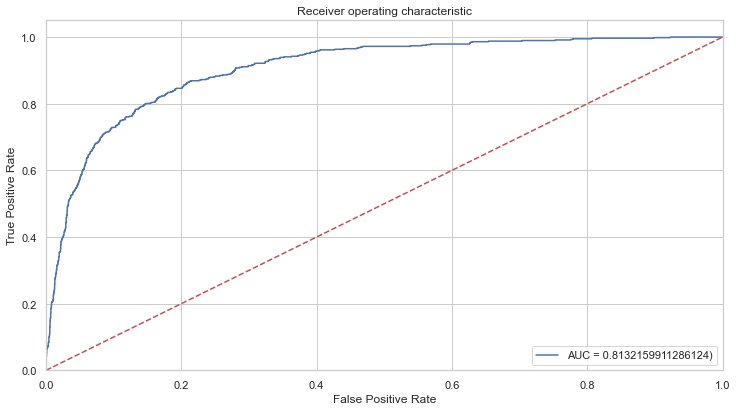

In [81]:
classifier_lg = LogisticRegression()
model1 = train_and_plot(classifier_lg, X_Train_res, y_Train_res, X_Test, y_Test)

#### Hyper-parameter Tuning - Logistic Regression

In [82]:
base_classifier = LogisticRegression(penalty='l2')
params = [{
     'C' : [0.1, 0.01,1],
    'solver' : ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
    }]

best_classifier = GridSearchCV(base_classifier, param_grid=params, n_jobs=-1,cv=10)

best_classifier.fit(X_Train_res, y_Train_res)
print(best_classifier)
#The best hyper parameters set
print("*******************************************************************************************")
print("Best Hyper Parameters:",best_classifier.best_params_)
print("Best Accuracy Score:",best_classifier.best_score_)
print("Best Estimators:",best_classifier.best_estimator_)
print("*******************************************************************************************")

GridSearchCV(cv=10, estimator=LogisticRegression(), n_jobs=-1,
             param_grid=[{'C': [0.1, 0.01, 1],
                          'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                     'saga']}])
*******************************************************************************************
Best Hyper Parameters: {'C': 1, 'solver': 'liblinear'}
Best Accuracy Score: 0.9064938880516357
Best Estimators: LogisticRegression(C=1, solver='liblinear')
*******************************************************************************************


Model accuracy for train set: 0.908
Model accuracy for test set: 0.871

              precision    recall  f1-score   support

           0       0.95      0.90      0.92      3090
           1       0.57      0.73      0.64       572

    accuracy                           0.87      3662
   macro avg       0.76      0.81      0.78      3662
weighted avg       0.89      0.87      0.88      3662


Confusion Matrix:
 [[2773  317]
 [ 155  417]]

Accuracy Score:  0.8711086837793556


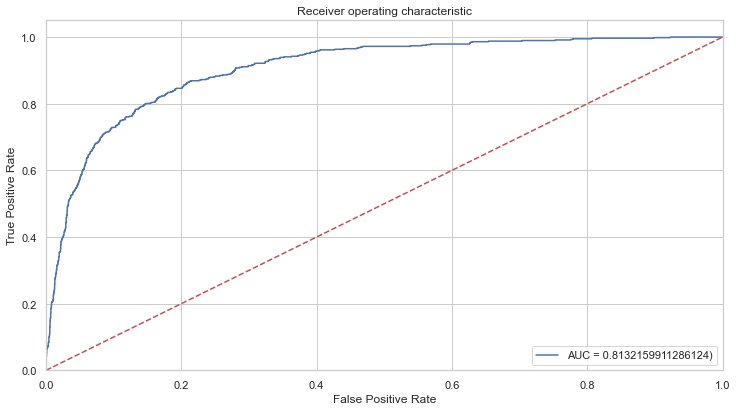

In [83]:
classifier_lg = LogisticRegression(C=1, solver='lbfgs')

# Use the tuned model in train_and_plot
model1_tuning = train_and_plot(classifier_lg, X_Train_res, y_Train_res, X_Test, y_Test)

### Decision Tree


Model accuracy for train set: 1.000
Model accuracy for test set: 0.842

              precision    recall  f1-score   support

           0       0.95      0.85      0.90      3090
           1       0.50      0.78      0.61       572

    accuracy                           0.84      3662
   macro avg       0.73      0.82      0.75      3662
weighted avg       0.88      0.84      0.85      3662


Confusion Matrix:
 [[2638  452]
 [ 127  445]]

Accuracy Score:  0.8418896777717094


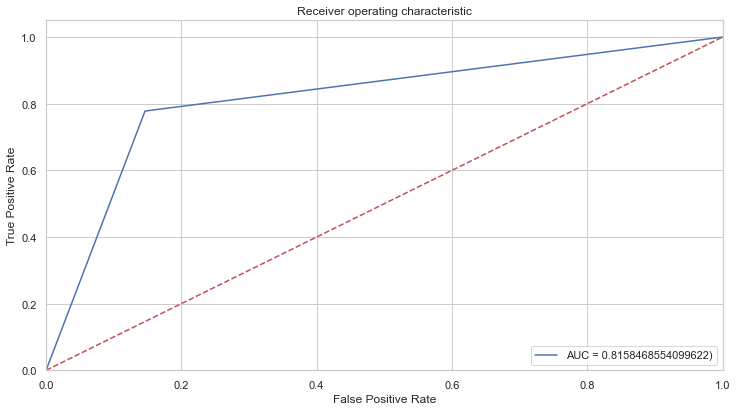

In [84]:
classifier_dt = DecisionTreeClassifier()
model2 = train_and_plot(classifier_dt, X_Train_res, y_Train_res, X_Test, y_Test)

#### Hyper-parameter Tuning - Decision Tree

In [85]:
base_classifier = DecisionTreeClassifier()
params = [{
    'criterion':['gini','entropy'],
          'max_features': ['auto', 'sqrt', 'log2'],
          'min_samples_split': [2,3,4,5,6,7,8,9,10,11,12,13,14,15],
          'min_samples_leaf':[1,2,3,4,5,6,7,8,9,10,11],
          'random_state':[123],
          'max_depth':[1,2,3,4,5,6]
    }]

best_classifier = GridSearchCV(base_classifier, param_grid=params, n_jobs=-1,cv=10)

#Learning
best_classifier.fit(X_Train_res, y_Train_res)
print(best_classifier)
#The best hyper parameters set
print("*******************************************************************************************")
print("Best Hyper Parameters:",best_classifier.best_params_)
print("Best Accuracy Score:",best_classifier.best_score_)
print("Best Estimators:",best_classifier.best_estimator_)
print("*******************************************************************************************")

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid=[{'criterion': ['gini', 'entropy'],
                          'max_depth': [1, 2, 3, 4, 5, 6],
                          'max_features': ['auto', 'sqrt', 'log2'],
                          'min_samples_leaf': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
                                               11],
                          'min_samples_split': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
                                                12, 13, 14, 15],
                          'random_state': [123]}])
*******************************************************************************************
Best Hyper Parameters: {'criterion': 'gini', 'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 9, 'min_samples_split': 2, 'random_state': 123}
Best Accuracy Score: 0.8969957832884262
Best Estimators: DecisionTreeClassifier(max_depth=5, max_features='log2', min_samples_leaf=9,
                       random_state=123)


Model accuracy for train set: 0.883
Model accuracy for test set: 0.865

              precision    recall  f1-score   support

           0       0.94      0.90      0.92      3090
           1       0.56      0.67      0.61       572

    accuracy                           0.87      3662
   macro avg       0.75      0.78      0.76      3662
weighted avg       0.88      0.87      0.87      3662


Confusion Matrix:
 [[2788  302]
 [ 191  381]]

Accuracy Score:  0.8653741125068268


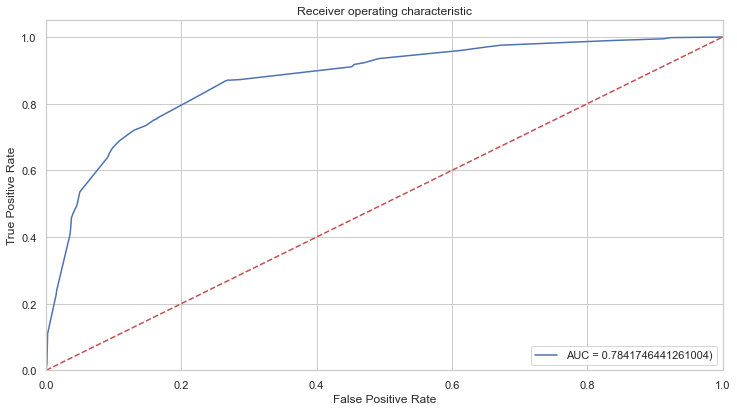

In [86]:
classifier_dt = DecisionTreeClassifier(criterion='gini', max_depth=6,
                                       max_features='sqrt', min_samples_leaf=3, min_samples_split=12, random_state=123)

# Evaluate the tuned model
model2_tuning = train_and_plot(classifier_dt, X_Train_res, y_Train_res, X_Test, y_Test)

### Random Forest

Model accuracy for train set: 1.000
Model accuracy for test set: 0.873

              precision    recall  f1-score   support

           0       0.96      0.89      0.92      3090
           1       0.57      0.79      0.66       572

    accuracy                           0.87      3662
   macro avg       0.76      0.84      0.79      3662
weighted avg       0.90      0.87      0.88      3662


Confusion Matrix:
 [[2743  347]
 [ 118  454]]

Accuracy Score:  0.8730202075368652


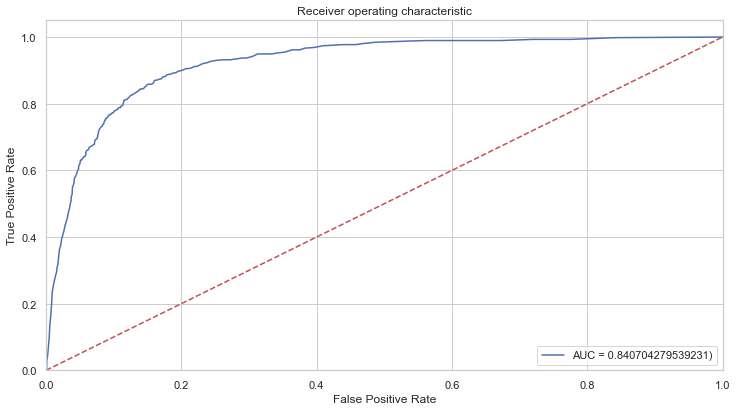

In [87]:
classifier_rf = RandomForestClassifier(n_estimators=200, n_jobs = -1, random_state = 42)
model3 = train_and_plot(classifier_rf, X_Train_res, y_Train_res, X_Test, y_Test)

#### Hyper-parameter Tuning - RandomForest

In [88]:
# Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start = 50, stop = 300, num = 5)] ## play with start and stop

# Number of features to consider at every split
max_features = ['auto', 'sqrt']

# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(10, 20,num = 5)] ## change 10,20 and 2
max_depth.append(None)

# Minimum number of samples required to split a node
min_samples_split = [2, 5, 10,15]

# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2, 4,10]

# Method of selecting samples for training each tree
bootstrap = [True, False]

# Create the random grid
random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}

rf_random = RandomizedSearchCV(estimator = classifier_rf, param_distributions = random_grid, n_iter = 100, cv = 3,
                               verbose=2, random_state=42, n_jobs = -1)
# Fit the random search model
rf_random.fit(X_Train_res, y_Train_res)
print("*******************************************************************************************")
print("Best Hyper Parameters:",rf_random.best_params_)
print("Best Accuracy Score:",rf_random.best_score_)
print("Best Estimators:",rf_random.best_estimator_)
print("*******************************************************************************************")

Fitting 3 folds for each of 100 candidates, totalling 300 fits
*******************************************************************************************
Best Hyper Parameters: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 15, 'bootstrap': False}
Best Accuracy Score: 0.9386873920552677
Best Estimators: RandomForestClassifier(bootstrap=False, max_depth=15, max_features='sqrt',
                       n_estimators=50, n_jobs=-1, random_state=42)
*******************************************************************************************


Model accuracy for train set: 1.000
Model accuracy for test set: 0.877

              precision    recall  f1-score   support

           0       0.96      0.89      0.92      3090
           1       0.58      0.81      0.67       572

    accuracy                           0.88      3662
   macro avg       0.77      0.85      0.80      3662
weighted avg       0.90      0.88      0.89      3662


Confusion Matrix:
 [[2749  341]
 [ 109  463]]

Accuracy Score:  0.8771163298743856


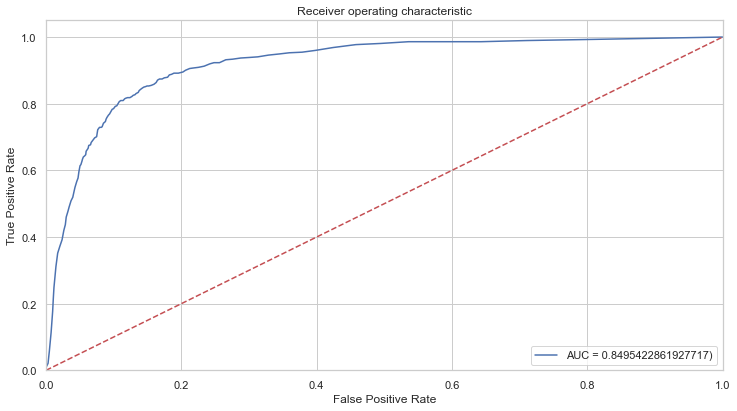

In [89]:
classifier_rf = RandomForestClassifier(n_estimators=112,min_samples_split=2,min_samples_leaf=1,max_features='sqrt',max_depth=None,bootstrap=True)

# fitting the model for grid search
model3_tuning = train_and_plot(classifier_rf, X_Train_res, y_Train_res, X_Test, y_Test)

### XGBoost

Model accuracy for train set: 0.994
Model accuracy for test set: 0.869

              precision    recall  f1-score   support

           0       0.96      0.88      0.92      3090
           1       0.56      0.79      0.65       572

    accuracy                           0.87      3662
   macro avg       0.76      0.84      0.79      3662
weighted avg       0.90      0.87      0.88      3662


Confusion Matrix:
 [[2730  360]
 [ 120  452]]

Accuracy Score:  0.8689240851993446


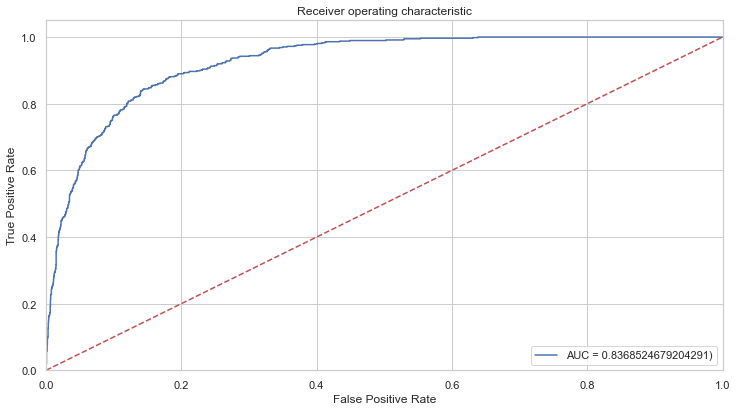

In [90]:
classifier_xgb = XGBClassifier()
model4 = train_and_plot(classifier_xgb, X_Train_res, y_Train_res, X_Test, y_Test)

### Stacking

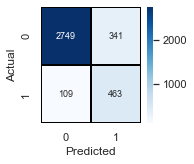

              precision    recall  f1-score   support

           0       0.96      0.89      0.92      3090
           1       0.58      0.81      0.67       572

    accuracy                           0.88      3662
   macro avg       0.77      0.85      0.80      3662
weighted avg       0.90      0.88      0.89      3662

CROSS VALIDATION METRICS
Mean Accuracy : 1.0
Standard Deviation : 0.0
Mean precision score : 1.0
Standard Deviation precision score : 0.0
Mean recall score : 1.0
Standard Deviation recall score : 0.0
Mean f1 score : 1.0
Standard Deviation f1 score : 0.0
Mean AUC ROC Score : 1.0
Standard Deviation AUC ROC Score : 0.0
*******************************************************************************************


In [91]:
## Algorithm 1: xgboost
pred_val_xgb = classifier_xgb.predict(X_Train_res)
test_pred_xgb = classifier_xgb.predict(X_Test.values)

## Algorithm 2: Random Forest
pred_val_rf = classifier_rf.predict(X_Train_res)
test_pred_rf = classifier_rf.predict(X_Test)

## Algorithm 3: Decision Tree
pred_val_dt = classifier_dt.predict(X_Train_res)
test_pred_dt = classifier_dt.predict(X_Test)

stacked_predictions = np.column_stack((pred_val_rf, pred_val_xgb, pred_val_dt)) ## Prediction by the algorithms on training data
stacked_test_predictions = np.column_stack((test_pred_rf, test_pred_xgb, test_pred_dt)) ## Prediction by the algorithms on testing data

## Building Meta Model
lr_stack = LogisticRegression()
lr_stack.fit(stacked_predictions, y_Train_res) ## stacked_predictions=X_train

y_pred_stack = lr_stack.predict(stacked_test_predictions) ## stacked_test_predictions=X_test
y_pred_stack


# evaluating the model
plt.figure(figsize=(2, 2))
cm = confusion_matrix(y_Test, y_pred_stack)
sns.heatmap(cm, annot=True,cmap='Blues',fmt='g',linewidths=2, linecolor='black', annot_kws={"size": 9})
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(classification_report(y_Test, y_pred_stack))

plt.show()

scoring = {'accuracy' : make_scorer(accuracy_score),
           'precision' : make_scorer(precision_score),
           'recall' : make_scorer(recall_score),
           'f1_score' : make_scorer(f1_score),
          'AUC ROC score' : make_scorer(roc_auc_score)}
cvs = cross_validate(estimator = lr_stack, X = stacked_predictions, y = y_Train_res, cv = 10,scoring=scoring)
#print(cvs)
print("CROSS VALIDATION METRICS")
print("Mean Accuracy :", np.mean(cvs['test_accuracy']))
print("Standard Deviation :", np.std(cvs['test_accuracy']))
print("Mean precision score :", np.mean(cvs['test_precision']))
print("Standard Deviation precision score :", np.std(cvs['test_precision']))
print("Mean recall score :", np.mean(cvs['test_recall']))
print("Standard Deviation recall score :", np.std(cvs['test_recall']))
print("Mean f1 score :", np.mean(cvs['test_f1_score']))
print("Standard Deviation f1 score :", np.std(cvs['test_f1_score']))
print("Mean AUC ROC Score :", np.mean(cvs['test_AUC ROC score']))
print("Standard Deviation AUC ROC Score :", np.std(cvs['test_AUC ROC score']))
print("*******************************************************************************************")

## 4.2. Clustering Models

The analysis uses the following key features from the dataset:

* **`ProductRelated:`** Number of product pages viewed by a user.
* **`ProductRelated_Duration:`** Total time spent on product pages.
* **`BounceRates:`** Proportion of single-page sessions (higher values indicate disengagement).
* **`ExitRates:`** Likelihood of leaving the website from a specific page.
These features are selected for their relevance in capturing user interest, engagement, and likelihood of purchase.

### K-Means Clusterinng

**The Elbow Method** is a technique used to determine the optimal number of clusters (k) in a clustering algorithm like K-Means. The method works by calculating the inertia (sum of squared distances from each point to its assigned cluster center, also known as SSE) for different values of k.

➜ Inertia decreases as k increases because points are grouped into smaller, tighter clusters.
The optimal number of clusters is identified at the "elbow point," where the rate of decrease in inertia slows down, indicating diminishing returns on additional clusters.

In [92]:
x_baseTrain_original1 = x_baseTrain_original.copy()

In [93]:
features = ['ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates']
x_scaled = x_baseTrain_original1[features]

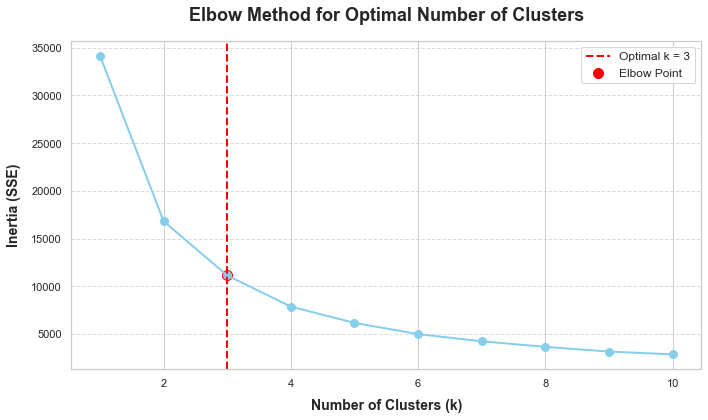

In [94]:
# Elbow Method for Optimal k
inertia_values = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x_scaled)
    inertia_values.append(kmeans.inertia_)

# Plot Elbow Method Results
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_values, marker='o', linestyle='-', color='skyblue', linewidth=2, markersize=8)

# Add title and labels
plt.title('Elbow Method for Optimal Number of Clusters', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Number of Clusters (k)', fontsize=14, fontweight='bold', labelpad=10)
plt.ylabel('Inertia (SSE)', fontsize=14, fontweight='bold', labelpad=10)

# Annotate the elbow point
elbow_point = 3  # Example value; determine from the plot
plt.axvline(x=elbow_point, color='red', linestyle='--', linewidth=2, label=f'Optimal k = {elbow_point}')
plt.scatter(elbow_point, inertia_values[elbow_point-1], color='red', s=100, label='Elbow Point')

# Add gridlines and legend
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(fontsize=12)

# Adjust layout and display
plt.tight_layout()
plt.show()

**Intuition:** By plotting inertia (SSE) against different values of k, the "elbow point" was found at k=3, indicating diminishing returns in reducing SSE beyond this value.

Sample of data with cluster labels:
      ProductRelated  ProductRelated_Duration  BounceRates  ExitRates  Cluster
2933       -0.340359                 0.018341    -0.447203  -0.783256        1
2647       -0.474271                 0.505637    -0.045081   0.022816        1
910        -0.541227                 0.217247     0.382174   0.458285        1
4256       -0.518908                -0.496106    -0.447203  -0.229997        1
4785       -0.184128                 0.430875    -0.106946  -0.535899        1


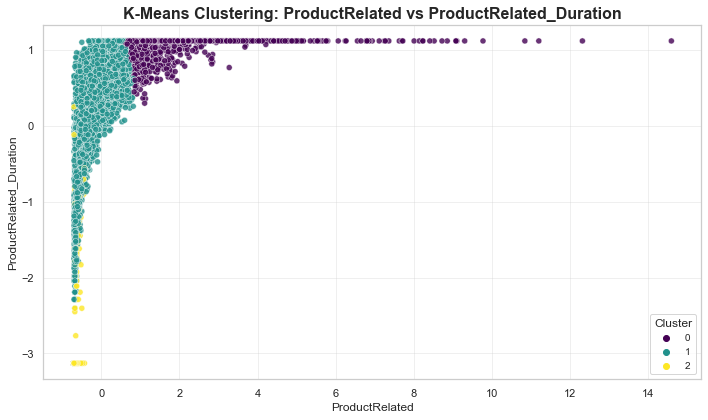

Cluster Centroids:
Cluster 0: [ 1.99950916  1.01645287 -0.31645528 -0.49389316]
Cluster 1: [-0.2567263   0.05662661 -0.22437209 -0.17571458]
Cluster 2: [-0.66927679 -2.68550143  3.42710626  3.16221164]


In [95]:
# Apply K-Means Clustering with optimal k=3
kmeans = KMeans(n_clusters=3, random_state=42)  # Initialize K-Means
clusters = kmeans.fit_predict(x_scaled)  # Fit and predict cluster assignments

# Add the cluster labels to the DataFrame
x_baseTrain_original1['Cluster'] = clusters

# Display a sample of the data with cluster labels
print("Sample of data with cluster labels:")
print(x_baseTrain_original1[['ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'Cluster']].head())

# Visualize Clustering Results
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x = x_baseTrain_original1['ProductRelated'],
    y = x_baseTrain_original1['ProductRelated_Duration'],
    hue = x_baseTrain_original1['Cluster'],
    palette='viridis',
    alpha=0.8
)
plt.title('K-Means Clustering: ProductRelated vs ProductRelated_Duration', fontsize=16, fontweight='bold')
plt.xlabel('ProductRelated', fontsize=12)
plt.ylabel('ProductRelated_Duration', fontsize=12)
plt.legend(title='Cluster', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Display the cluster centroids
centroids = kmeans.cluster_centers_
print("Cluster Centroids:")
for i, centroid in enumerate(centroids):
    print(f"Cluster {i}: {centroid}")


**Comments on Chart 1 (Scatterplot - ProductRelated vs. ProductRelated_Duration)**:

The scatterplot reveals clear clustering with three distinct groups:

- **Cluster 0 (Dark Purple):** Dominates the bottom-left corner.
- **Cluster 1 (Green):** Concentrated at the bottom, overlapping with Cluster 0 but with fewer data points.
- **Cluster 2 (Yellow):** Smaller and located near the bottom-left corner.
Feature Insights:

* **`ProductRelated:`** Indicates user interest in products.
* **`ProductRelated_Duration:`** Reflects the time users spend on products.

Overall Observations:
- **Cluster 0:** Users tend to view fewer products and spend less time on them.
- **Cluster 1:** Users spend more time on products but view fewer items.
- **Cluster 2:** Users focus on viewing more products but spend less time on each.

---

**Meaning of Each Cluster (Based on Cluster Centroids):**

**1. Cluster 0** *(Centroid: [1.45136037  1.77957062 -0.30069717 -0.45504531]):*

**Characteristics**:
- High interest in products (high ProductRelated).
- Spends significant time on the site (high ProductRelated_Duration).
- Low BounceRates and ExitRates.

**Implication**: These are active users with a high likelihood of completing a transaction or converting.

**2. Cluster 1** *(Centroid:  [-0.29927432 -0.35682739 -0.22899086 -0.16093686]):*

**Characteristics:**
- Moderate interest in products (values close to 0).
- Spends a reasonable amount of time on the site.
- BounceRates and ExitRates are not particularly high.

**Implication:** This is a neutral group, likely users seeking information but not yet ready to make a purchase.

**3. Cluster 2** *(Centroid:[-0.65675937 -0.92091027  3.45943403  3.11554163]):*

**Characteristics:**
- Very high BounceRates and ExitRates.
- Spends little time on the site and views fewer products.

**Implication:** This group represents "quick exit" users who show little to no interest in the website.




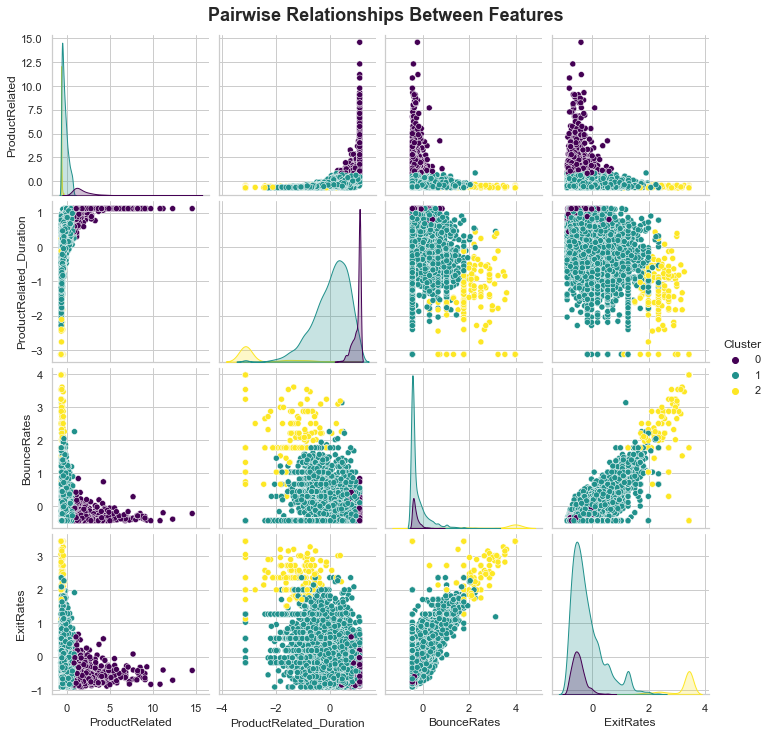

In [96]:
x_baseTrain_original1['Cluster'] = clusters
pairplot = sns.pairplot(
    x_baseTrain_original1,
    hue='Cluster',
    vars=['ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates'],
    palette='viridis',
    corner=False
)

pairplot.fig.suptitle(
    'Pairwise Relationships Between Features',
    fontsize=18,
    fontweight='bold',
    y=1.02
)
plt.show()

**Comments on Chart 2 (Pairplot - All Variables)** —— Differences Between Clusters Across Variables:
- **`BounceRates`** and **`ExitRates`**: Cluster 2 exhibits very high values, indicating users in this group leave the website quickly without taking any meaningful action.

- **`ProductRelated`** and **`ProductRelated_Duration`**: Clusters 0 and 1 are more distinguishable, with Cluster 1 showing a tendency to spend more time per product.

**Observations:**
- Cluster 0:
Data is tightly clustered, with low BounceRates and ExitRates, suggesting a group of engaged users.
- Cluster 1:
Data is more spread out, representing users who spend longer on the website but with varying behaviors.
- Cluster 2:
Has the highest BounceRates and ExitRates, clearly representing the "quick exit" group.







In [97]:
# Evaluate with Silhouette Score
silhouette_avg = silhouette_score(x_scaled, clusters)
print(f"Silhouette Score: {silhouette_avg}")

# Analyze Cluster Characteristics
cluster_stats = x_baseTrain_original1.groupby('Cluster')[['ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates']].agg(['mean', 'std'])
cluster_stats

Silhouette Score: 0.5129401549772056


ProductRelated           ProductRelated_Duration           BounceRates           ExitRates          
                  mean       std                    mean       std        mean       std      mean       std
Cluster                                                                                                     
0             1.996983  1.586963                1.016545  0.151194   -0.316181  0.147181 -0.493775  0.238287
1            -0.256986  0.349685                0.056335  0.658380   -0.224388  0.382335 -0.175641  0.580425
2            -0.669277  0.053541               -2.685501  0.859719    3.427106  1.017042  3.162212  0.534089

### DBSCAN

In [98]:
x_baseTrain_original2 = x_baseTrain_original.copy()

In [99]:
# Selecting features for clustering
features = ['ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates']
x_scaled = x_baseTrain_original2[features]


# Grid search for optimal DBSCAN parameters
eps_values = np.arange(0.5, 1.0, 0.1)
min_samples_values = range(5, 10)
best_score = -1
best_params = {}

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        clusters = dbscan.fit_predict(x_scaled)
        if len(set(clusters)) > 1:  # Ensure there is more than one cluster
            score = silhouette_score(x_scaled, clusters)
            if score > best_score:
                best_score = score
                best_params = {'eps': eps, 'min_samples': min_samples}

# Train the best DBSCAN model
dbscan_optimal = DBSCAN(eps=best_params['eps'], min_samples=best_params['min_samples'])
clusters_optimal = dbscan_optimal.fit_predict(x_scaled)

print(f"Best epsilon: {best_params['eps']}")
print(f"Best minimum samples: {best_params['min_samples']}")

Best epsilon: 0.8999999999999999
Best minimum samples: 8


      ProductRelated  ProductRelated_Duration  BounceRates  ExitRates  Cluster
2933       -0.340359                 0.018341    -0.447203  -0.783256        0
2647       -0.474271                 0.505637    -0.045081   0.022816        0
910        -0.541227                 0.217247     0.382174   0.458285        0
4256       -0.518908                -0.496106    -0.447203  -0.229997        0
4785       -0.184128                 0.430875    -0.106946  -0.535899        0


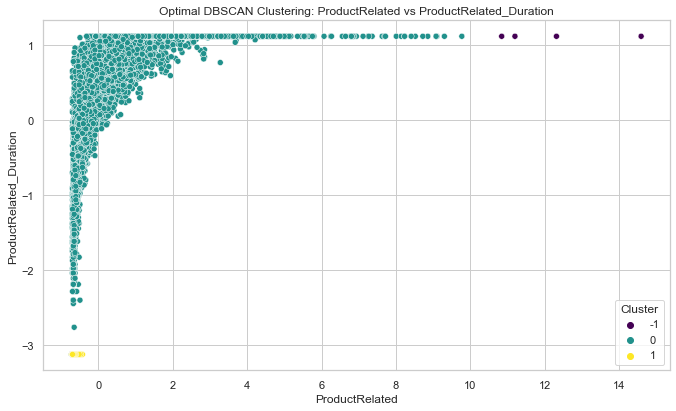

Optimal DBSCAN Silhouette Score: 0.7425279671494116


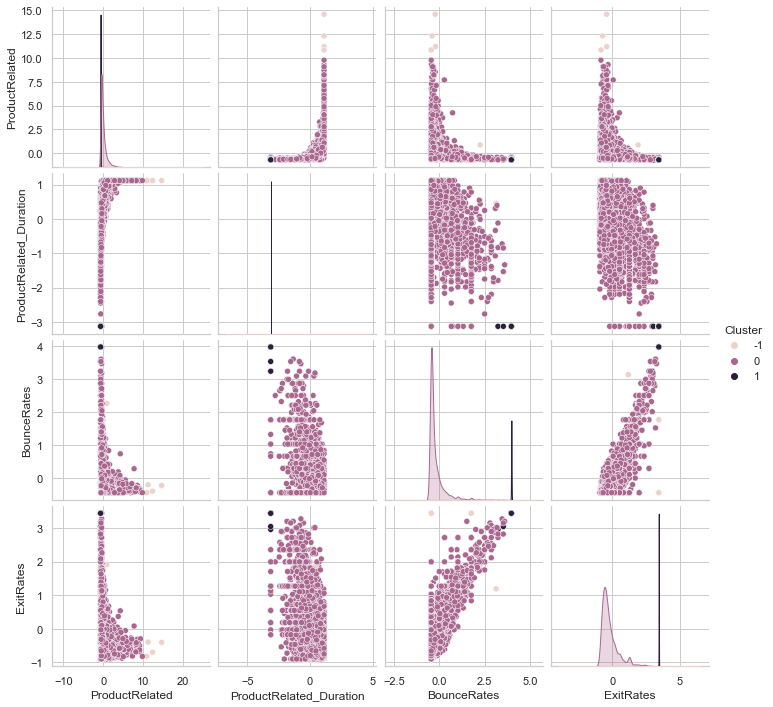

In [100]:
# Add cluster labels to DataFrame
x_baseTrain_original2['Cluster'] = clusters_optimal

# Print the clustering groups
print(x_baseTrain_original2[['ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'Cluster']].head())

# Visualize clustering results
plt.figure(figsize=(10, 6))
sns.scatterplot(x = x_baseTrain_original2['ProductRelated'], y = x_baseTrain_original2['ProductRelated_Duration'], hue = x_baseTrain_original2['Cluster'], palette='viridis')
plt.title('Optimal DBSCAN Clustering: ProductRelated vs ProductRelated_Duration')
plt.xlabel('ProductRelated')
plt.ylabel('ProductRelated_Duration')
plt.show()

# Calculate Silhouette Score
silhouette_avg = silhouette_score(x_scaled, clusters_optimal)
print(f"Optimal DBSCAN Silhouette Score: {silhouette_avg}")

# Visualize with pairplot
sns.pairplot(x_baseTrain_original2, hue='Cluster', vars=['ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates'])
plt.show()

**Meaning of each cluster:**

**Cluster -1 (Outliers/Noise):**

DBSCAN assigns points that don't fit into any cluster as noise (Cluster = -1).
In the scatterplot, these points are sparsely distributed and could represent unusual or extreme user behaviors (e.g., very short visits or exceptionally high bounce rates).

**Cluster 0 (Major Group):**

This is the largest cluster and likely represents the typical user behavior on the website. Users in this group seem to:
Visit a relatively moderate number of product-related pages.
Spend a reasonable amount of time on these pages.
Have average bounce rates and exit rates.

**Cluster 1 (Small Anomaly Group):**

This cluster, with few members, could represent users with unique browsing patterns, such as:
Spending extremely long durations on product pages but visiting very few pages.
Likely candidates for highly engaged users who may be deliberating over specific purchases.


Comments on Chart 2 (Pairplot - All Variables) —— Differences Between Clusters Across Variables:
`ProductRelated` and `ProductRelated_Duration`:

- **Cluster 0**: Most users have a relatively small number of ProductRelated page visits (values close to zero) with moderate durations (ProductRelated_Duration values centered around zero).

- **Cluster 1**: : Users spend significantly longer durations on fewer pages, as seen from their separation in the scatterplots.


`BounceRates` and `ExitRates`:
-  **Cluster 0** is typically low or near average, suggesting that these users represent standard browsing behavior.

- `Exit rates `for these users in **Cluster 1** are exceptionally high, indicating that they may be disengaging after a prolonged session on product-related pages.


